# Compare ICESat-2 and the Reanalysis product in the Upper Tuolumne River Basin Above Hetch Hetchy

In [1]:
import numpy as np 
import pandas as pd 
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import rioxarray as rxr
import pickle

### Read in the 2 tiles that make up the Upper Tuolumne River Basin below hetch hetchy, where I already have Icesat2 data to test against the reanalysis data:

In [246]:
reanalysis1_2019 = xr.open_dataset('../data/reanalysis/WUS_UCLA_SR_v01_N37_0W120_0_agg_16_WY2018_19_SD_POST.nc')
reanalysis2_2019 = xr.open_dataset('../data/reanalysis/WUS_UCLA_SR_v01_N38_0W120_0_agg_16_WY2018_19_SD_POST.nc')

reanalysis1_2020 = xr.open_dataset('../data/reanalysis/WUS_UCLA_SR_v01_N37_0W120_0_agg_16_WY2019_20_SD_POST.nc')
reanalysis2_2020 = xr.open_dataset('../data/reanalysis/WUS_UCLA_SR_v01_N38_0W120_0_agg_16_WY2019_20_SD_POST.nc')

reanalysis1_2021 = xr.open_dataset('../data/reanalysis/WUS_UCLA_SR_v01_N37_0W120_0_agg_16_WY2020_21_SD_POST.nc')
reanalysis2_2021 = xr.open_dataset('../data/reanalysis/WUS_UCLA_SR_v01_N38_0W120_0_agg_16_WY2020_21_SD_POST.nc')

fsca_reanalysis1_2019 = xr.open_dataset('../data/reanalysis/WUS_UCLA_SR_v01_N37_0W120_0_agg_16_WY2018_19_SWE_SCA_POST.nc')
fsca_reanalysis2_2019 = xr.open_dataset('../data/reanalysis/WUS_UCLA_SR_v01_N38_0W120_0_agg_16_WY2018_19_SWE_SCA_POST.nc')

fsca_reanalysis1_2020 = xr.open_dataset('../data/reanalysis/WUS_UCLA_SR_v01_N37_0W120_0_agg_16_WY2019_20_SWE_SCA_POST.nc')
fsca_reanalysis2_2020 = xr.open_dataset('../data/reanalysis/WUS_UCLA_SR_v01_N38_0W120_0_agg_16_WY2019_20_SWE_SCA_POST.nc')

fsca_reanalysis1_2021 = xr.open_dataset('../data/reanalysis/WUS_UCLA_SR_v01_N37_0W120_0_agg_16_WY2020_21_SWE_SCA_POST.nc')
fsca_reanalysis2_2021 = xr.open_dataset('../data/reanalysis/WUS_UCLA_SR_v01_N38_0W120_0_agg_16_WY2020_21_SWE_SCA_POST.nc')


In [245]:
reanalysis1_2019

<xarray.Dataset> Size: 370MB
Dimensions:    (Latitude: 225, Longitude: 225, Day: 365, Stats: 5)
Coordinates:
  * Latitude   (Latitude) float32 900B 38.0 37.99 37.99 ... 37.01 37.01 37.0
  * Longitude  (Longitude) float32 900B -120.0 -120.0 -120.0 ... -119.0 -119.0
Dimensions without coordinates: Day, Stats
Data variables:
    SD_Post    (Day, Stats, Longitude, Latitude) float32 370MB ...

In [24]:
tuol_outline = gpd.read_file('../data/UpperTuolRiverBasinOutline.geojson')

### Combine reanalysis tiles over the Tuolumne:

In [250]:
reanalysis_tuol_2019 = xr.combine_by_coords([reanalysis1_2019, reanalysis2_2019])

reanalysis_tuol_2020 = xr.combine_by_coords([reanalysis1_2020, reanalysis2_2020])

reanalysis_tuol_2021 = xr.combine_by_coords([reanalysis1_2021, reanalysis2_2021])

fsca_reanalysis_tuol_2019 = xr.combine_by_coords([fsca_reanalysis1_2019, fsca_reanalysis2_2019])

fsca_reanalysis_tuol_2020 = xr.combine_by_coords([fsca_reanalysis1_2020, fsca_reanalysis2_2020])

fsca_reanalysis_tuol_2021 = xr.combine_by_coords([fsca_reanalysis1_2021, fsca_reanalysis2_2021])

In [253]:
fsca_reanalysis_tuol_2021

<xarray.Dataset> Size: 1GB
Dimensions:    (Day: 365, Stats: 5, Longitude: 225, Latitude: 450)
Coordinates:
  * Latitude   (Latitude) float32 2kB 39.0 38.99 38.99 ... 37.01 37.01 37.0
  * Longitude  (Longitude) float32 900B -120.0 -120.0 -120.0 ... -119.0 -119.0
Dimensions without coordinates: Day, Stats
Data variables:
    SWE_Post   (Day, Stats, Longitude, Latitude) float32 739MB 0.0 0.0 ... 0.0
    SCA_Post   (Day, Stats, Longitude, Latitude) float32 739MB 0.0 0.0 ... 0.0

In [251]:
import datetime

def day_of_year(date):
    # Check if it's a leap year
    leap_year = date.year % 4 == 0 and (date.year % 100 != 0 or date.year % 400 == 0)
    
    # Define days in each month, accounting for leap year
    days_in_month = [31, 29 if leap_year else 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    
    # Calculate day of the year
    day_count = sum(days_in_month[i] for i in range(date.month - 1)) + date.day
    
    return day_count

# Example usage
date = datetime.date(2024, 5, 9)
print("Day of the year:", day_of_year(date))

Day of the year: 130


In [252]:
def subset_reanalysis(ds, out_fn):
    # read in and format large SWE Reanalysis file:
    
    #ds = xr.open_dataset(ds_fn)
    ds.rio.write_crs('EPSG:4326',inplace = True)
    if 'Latitude' in ds.dims:
        ds = ds.rename({'Latitude':'y','Longitude':'x'})
    
    ds = ds.rio.set_spatial_dims('y','x',inplace=True)

    # Subset to the correct day and statistic, and read out as a new file:
    ds_stat = ds.sel({'Stats': 2})
    ds_stat = ds_stat.SD_Post.T
    ds_stat.to_netcdf(out_fn)
    
    return ds_stat

### Preprocess the reanalysis data to give only the statistics we want (ensemble median):

In [9]:
!pwd

/Users/hannah/Documents/Grad_Documents/Research/analog_snowmapping/notebooks


In [249]:
reanalysis_processed_2019 = subset_reanalysis(reanalysis_tuol_2019,'../data/reanalysis/reanalysis_tuol_processed_2019.nc')

reanalysis_processed_2020 = subset_reanalysis(reanalysis_tuol_2020,'../data/reanalysis/reanalysis_tuol_processed_2020.nc')

reanalysis_processed_2021 = subset_reanalysis(reanalysis_tuol_2021,'../data/reanalysis/reanalysis_tuol_processed_2021.nc')

In [254]:
def subset_reanalysis(ds, out_fn):
    # read in and format large SWE Reanalysis file:
    
    #ds = xr.open_dataset(ds_fn)
    ds.rio.write_crs('EPSG:4326',inplace = True)
    if 'Latitude' in ds.dims:
        ds = ds.rename({'Latitude':'y','Longitude':'x'})
    
    ds = ds.rio.set_spatial_dims('y','x',inplace=True)

    # Subset to the correct day and statistic, and read out as a new file:
    ds_stat = ds.sel({'Stats': 2})
    ds_stat = ds_stat.SCA_Post.T
    ds_stat.to_netcdf(out_fn)
    
    return ds_stat

In [255]:
fsca_reanalysis_processed_2019 = subset_reanalysis(fsca_reanalysis_tuol_2019,'../data/reanalysis/reanalysis_tuol_processed_fsca_2019.nc')

fsca_reanalysis_processed_2020 = subset_reanalysis(fsca_reanalysis_tuol_2020,'../data/reanalysis/reanalysis_tuol_processed_fsca_2020.nc')

fsca_reanalysis_processed_2021 = subset_reanalysis(fsca_reanalysis_tuol_2021,'../data/reanalysis/reanalysis_tuol_processed_fsca_2021.nc')

<Axes: title={'center': 'spatial_ref = 0'}, xlabel='x', ylabel='y'>

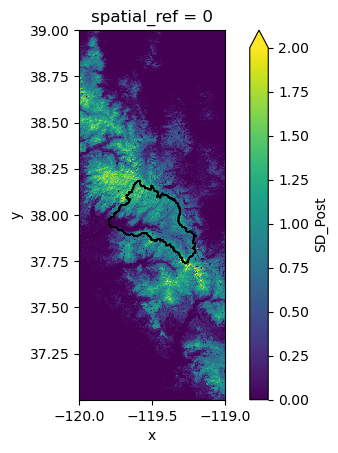

In [25]:
fig, ax = plt.subplots()
reanalysis_processed_2019[:,:,100].plot(ax=ax, vmax=2)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')


### Load ICESat-2 data from Masters work:

In [26]:
atl06sr_gdf = pickle.load(open('../data/icesat2/tuolumne_all_sr-atl06-09282022_processed_bicubic_snowonaso.pkl', 'rb'))

/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_22703/2397239878.py:1: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  atl06sr_gdf = pickle.load(open('../data/icesat2/tuolumne_all_sr-atl06-09282022_processed_bicubic_snowonaso.pkl', 'rb'))


In [27]:
atl06sr_gdf

,distance,h_sigma,rgt,delta_time,pflags,dh_fit_dy,segment_id,w_surface_window_final,dh_fit_dx,h_mean,...,site,acqdate,n,diff_plus,diff_plus_bicubic,zscore,ASO_snowon,ASO_snowon_date,ASO_snowon_bic,median_slope20d
time,,,,,,,,,,,,,,,,,,,,,
2018-10-15 23:22:20.018965444,4.215353e+06,0.033182,265,2.488094e+07,0,0.0,210188,3.000000,-0.018228,2501.377184,...,tuolumne,2018-10-15,919,-0.178201,-0.219547,-0.411177,NaN,NaN,NaN,NaN
2018-10-15 23:22:20.021811344,4.215373e+06,0.028329,265,2.488094e+07,0,0.0,210189,3.000000,-0.010939,2501.116873,...,tuolumne,2018-10-15,919,0.061488,-0.033683,-0.302681,NaN,NaN,NaN,NaN
2018-10-15 23:22:20.027481712,4.215413e+06,0.032855,265,2.488094e+07,0,0.0,210191,3.000000,-0.000515,2501.053838,...,tuolumne,2018-10-15,919,-0.011557,-0.072490,-0.325334,NaN,NaN,NaN,1.789189
2018-10-15 23:22:20.030305900,4.215434e+06,0.041974,265,2.488094e+07,0,0.0,210192,3.000000,0.008181,2501.176924,...,tuolumne,2018-10-15,919,0.171344,0.015610,-0.273906,NaN,NaN,NaN,1.543467
2018-10-15 23:22:20.033126928,4.215454e+06,0.045422,265,2.488094e+07,0,0.0,210193,3.000000,0.004802,2501.271832,...,tuolumne,2018-10-15,919,-0.173689,-0.122374,-0.354453,NaN,NaN,NaN,2.030019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-06-06 07:52:14.166292256,4.221955e+06,0.103436,1149,1.397371e+08,0,0.0,210520,8.424878,-0.329516,3501.549246,...,tuolumne,2022-06-06,2311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-06 07:52:14.174719728,4.222015e+06,0.101625,1149,1.397371e+08,0,0.0,210523,9.093066,-0.355783,3483.510153,...,tuolumne,2022-06-06,2311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-06 07:52:14.177525200,4.222035e+06,0.093427,1149,1.397371e+08,0,0.0,210524,10.206696,-0.399543,3476.005923,...,tuolumne,2022-06-06,2311,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Re-pickle because of deprecation warning:

In [28]:
atl06sr_gdf.to_pickle('../data/icesat2/tuolumne_all_sr-atl06-09282022_processed_bicubic_snowonaso_shapely.pkl')

In [29]:
atl06sr_gdf = pickle.load(open('../data/icesat2/tuolumne_all_sr-atl06-09282022_processed_bicubic_snowonaso_shapely.pkl', 'rb'))

In [45]:
atl06sr_gdf.columns

Index(['distance', 'h_sigma', 'rgt', 'delta_time', 'pflags', 'dh_fit_dy',
       'segment_id', 'w_surface_window_final', 'dh_fit_dx', 'h_mean', 'spot',
       'gt', 'cycle', 'rms_misfit', 'n_fit_photons', 'geometry', 'doy',
       'decyear', 'dowy', 'snow_presence', 'lidar_z', 'difference',
       'bicubic_lidar_z', 'sampling_dif', 'difference_bicubic', 'site',
       'acqdate', 'n', 'diff_plus', 'diff_plus_bicubic', 'zscore',
       'ASO_snowon', 'ASO_snowon_date', 'ASO_snowon_bic', 'median_slope20d'],
      dtype='object')

### Define relevant snow-on dates on which to compare IS2 and reanalysis:

In [41]:
snowon_dates = list(atl06sr_gdf[atl06sr_gdf['snow_presence']==1]['acqdate'].unique())

In [42]:
snowon_dates

[datetime.date(2018, 12, 11),
 datetime.date(2019, 1, 9),
 datetime.date(2019, 3, 12),
 datetime.date(2019, 4, 10),
 datetime.date(2019, 5, 14),
 datetime.date(2019, 12, 9),
 datetime.date(2019, 12, 11),
 datetime.date(2020, 1, 7),
 datetime.date(2020, 1, 13),
 datetime.date(2020, 2, 5),
 datetime.date(2020, 2, 11),
 datetime.date(2020, 3, 9),
 datetime.date(2020, 3, 10),
 datetime.date(2020, 4, 7),
 datetime.date(2020, 4, 12),
 datetime.date(2020, 12, 6),
 datetime.date(2020, 12, 8),
 datetime.date(2021, 1, 10),
 datetime.date(2021, 2, 2),
 datetime.date(2021, 2, 8),
 datetime.date(2021, 3, 7),
 datetime.date(2021, 3, 13),
 datetime.date(2021, 4, 5),
 datetime.date(2021, 4, 11),
 datetime.date(2021, 5, 10),
 datetime.date(2022, 1, 3),
 datetime.date(2022, 1, 8),
 datetime.date(2022, 2, 6),
 datetime.date(2022, 4, 3)]

<Axes: >

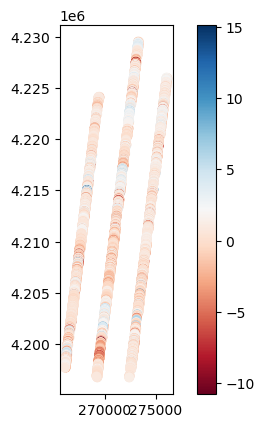

In [368]:
fig, ax = plt.subplots()
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[0])].plot(column='diff_plus_bicubic',ax=ax, legend=True, cmap='RdBu')

<Axes: title={'center': 'spatial_ref = 0'}, xlabel='x', ylabel='y'>

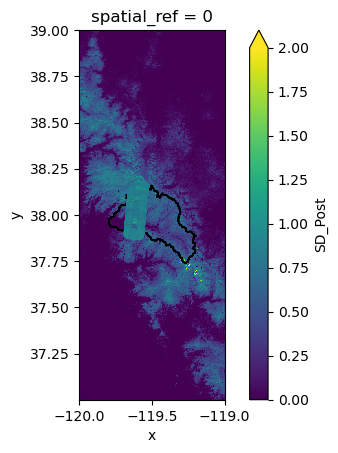

In [59]:
fig, ax = plt.subplots()
reanalysis_processed[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[0]]['dowy'].unique()].plot(ax=ax, vmax=2)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[0])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax)

### Calculate median snow depth over the entire basin:

In [135]:
reanalysis_clipped_2019 = reanalysis_processed_2019.rio.clip(tuol_outline.geometry)

reanalysis_clipped_2020 = reanalysis_processed_2020.rio.clip(tuol_outline.geometry)

reanalysis_clipped_2021 = reanalysis_processed_2021.rio.clip(tuol_outline.geometry)

In [256]:
fsca_reanalysis_clipped_2019 = fsca_reanalysis_processed_2019.rio.clip(tuol_outline.geometry)

fsca_reanalysis_clipped_2020 = fsca_reanalysis_processed_2020.rio.clip(tuol_outline.geometry)

fsca_reanalysis_clipped_2021 = fsca_reanalysis_processed_2021.rio.clip(tuol_outline.geometry)

Not sure how to deal with snow-off values in the ICESat-2 data. I exclude 0 values in the reanalysis data, but then do I use a current-year snow cover product, or brightness values in the ICESat-2 data? I showed that brightness values could be used in Tuolumne (as did Cesar) but not in the Methow, so is it still valid to use the in the Sierra?

### Populate a columne of the is2 dataframe with fsca sampled from the reanalysis on the corresponding date:

In [360]:
date_index=0

x_coord = [pt.x for pt in atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').geometry]
y_coord = [pt.y for pt in atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').geometry]

atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]), ['reanalysis_fsca']] = reanalysis_fsca.sel(x=x_coord, y=y_coord, method='nearest').values.diagonal().T.squeeze()

In [305]:
snowon_dates[0:5]


[datetime.date(2018, 12, 11),
 datetime.date(2019, 1, 9),
 datetime.date(2019, 3, 12),
 datetime.date(2019, 4, 10),
 datetime.date(2019, 5, 14)]

In [306]:
snowon_dates[5:15]

[datetime.date(2019, 12, 9),
 datetime.date(2019, 12, 11),
 datetime.date(2020, 1, 7),
 datetime.date(2020, 1, 13),
 datetime.date(2020, 2, 5),
 datetime.date(2020, 2, 11),
 datetime.date(2020, 3, 9),
 datetime.date(2020, 3, 10),
 datetime.date(2020, 4, 7),
 datetime.date(2020, 4, 12)]

In [310]:
snowon_dates[15:25]

[datetime.date(2020, 12, 6),
 datetime.date(2020, 12, 8),
 datetime.date(2021, 1, 10),
 datetime.date(2021, 2, 2),
 datetime.date(2021, 2, 8),
 datetime.date(2021, 3, 7),
 datetime.date(2021, 3, 13),
 datetime.date(2021, 4, 5),
 datetime.date(2021, 4, 11),
 datetime.date(2021, 5, 10)]

In [362]:
# 2019:

for date_index in snowon_dates[0:5]:
    reanalysis_fsca = fsca_reanalysis_clipped_2019[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==date_index]['dowy'].unique()]
    x_coord = [pt.x for pt in atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==date_index)].to_crs('epsg:4326').geometry]
    y_coord = [pt.y for pt in atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==date_index)].to_crs('epsg:4326').geometry]
    atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==date_index), ['reanalysis_fsca']] = reanalysis_fsca.sel(x=x_coord, y=y_coord, method='nearest').values.diagonal().T

# 2020:

for date_index in snowon_dates[5:15]:
    reanalysis_fsca = fsca_reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==date_index]['dowy'].unique()]
    x_coord = [pt.x for pt in atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==date_index)].to_crs('epsg:4326').geometry]
    y_coord = [pt.y for pt in atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==date_index)].to_crs('epsg:4326').geometry]
    atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==date_index), ['reanalysis_fsca']] = reanalysis_fsca.sel(x=x_coord, y=y_coord, method='nearest').values.diagonal().T

# 2021:

for date_index in snowon_dates[15:25]:
    reanalysis_fsca = fsca_reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==date_index]['dowy'].unique()]
    x_coord = [pt.x for pt in atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==date_index)].to_crs('epsg:4326').geometry]
    y_coord = [pt.y for pt in atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==date_index)].to_crs('epsg:4326').geometry]
    atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==date_index), ['reanalysis_fsca']] = reanalysis_fsca.sel(x=x_coord, y=y_coord, method='nearest').values.diagonal().T

### Sample the reanalysis snow depth at IS2 points on corresponding dates:

In [440]:
atl06sr_gdf['reanalysis_sd'] = np.nan

# 2019:

for date_index in snowon_dates[0:5]:
    reanalysis = reanalysis_clipped_2019[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==date_index]['dowy'].unique()]
    x_coord = [pt.x for pt in atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==date_index)].to_crs('epsg:4326').geometry]
    y_coord = [pt.y for pt in atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==date_index)].to_crs('epsg:4326').geometry]
    atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==date_index), ['reanalysis_sd']] = reanalysis.sel(x=x_coord, y=y_coord, method='nearest').values.diagonal().T

# 2020:

for date_index in snowon_dates[5:15]:
    reanalysis = reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==date_index]['dowy'].unique()]
    x_coord = [pt.x for pt in atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==date_index)].to_crs('epsg:4326').geometry]
    y_coord = [pt.y for pt in atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==date_index)].to_crs('epsg:4326').geometry]
    atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==date_index), ['reanalysis_sd']] = reanalysis.sel(x=x_coord, y=y_coord, method='nearest').values.diagonal().T

# 2021:

for date_index in snowon_dates[15:25]:
    reanalysis = reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==date_index]['dowy'].unique()]
    x_coord = [pt.x for pt in atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==date_index)].to_crs('epsg:4326').geometry]
    y_coord = [pt.y for pt in atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==date_index)].to_crs('epsg:4326').geometry]
    atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==date_index), ['reanalysis_sd']] = reanalysis.sel(x=x_coord, y=y_coord, method='nearest').values.diagonal().T

<Axes: >

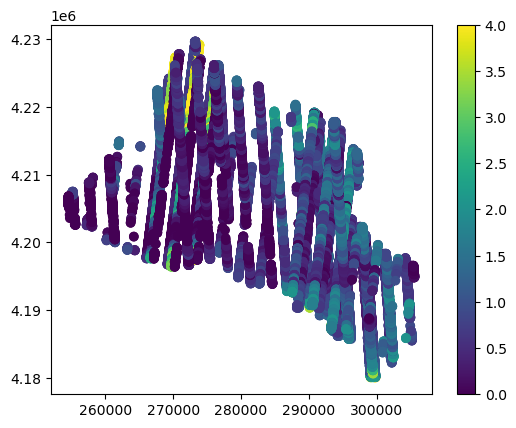

In [444]:
atl06sr_gdf.plot(column='reanalysis_sd', legend=True, vmax=4)

In [445]:
atl06sr_gdf['reanalysis_dif'] = atl06sr_gdf['diff_plus_bicubic'] - atl06sr_gdf['reanalysis_sd']

In [449]:
len(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']>0.1),['reanalysis_dif']])

67006

In [450]:
np.sqrt(len(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']>0.1),['reanalysis_dif']]))

np.float64(258.85517186256874)

''

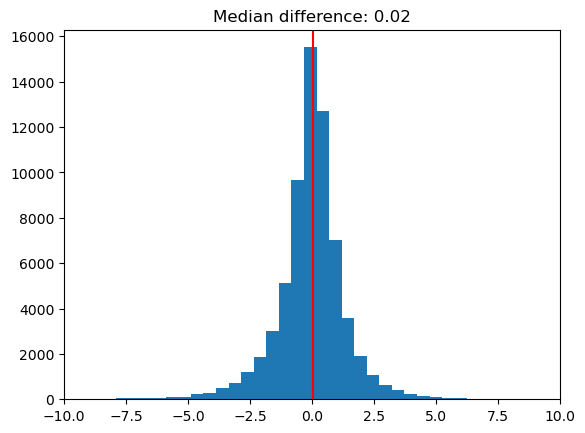

In [458]:
fig, ax = plt.subplots()

ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']>0.1),['reanalysis_dif']], bins=250)
ax.set_xlim(-10,10)
ax.axvline(x=np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']>0.1),['reanalysis_dif']]), c='red')
ax.set_title(f'Median difference: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']>0.1),['reanalysis_dif']]):.2f}')
;

### Calculate MAE  
Fastest/easiest way to do this is just sample the reanalysis snow depth at each is2 point on the corresonponding dates.  
  
Fancier/lonI could do what I did when I compared IS2 to ASO at the 500 m scale - make a fishnet aligned with the reanalysis grid, turn the pixels into polygons, and calculate the median/mean IS2 within each polygon. 

In [462]:
from sklearn.metrics import mean_absolute_error as mae

date_index=0

error = np.nanmean(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['reanalysis_dif'])

# reanalysis_test = reanalysis_clipped_2019[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
# reanalysis_fsca = fsca_reanalysis_clipped_2019[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# reanalysis_sd = atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['reanalysis_sd']
# atl06sr_sd = atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']

# reanalysis_sd_nans = reanalysis_sd[~np.isnan(reanalysis_sd)]
# atl06sr_sd_nans = atl06sr_sd[~np.isnan(atl06sr_sd)]

# error = mae(reanalysis_sd_nans, atl06sr_sd_nans)

In [463]:
error

np.float64(-0.0949391848240409)

In [465]:
errors = []

for date_index in snowon_dates:
    error = np.nanmean(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==date_index) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['reanalysis_dif'])
    errors.append(error)

/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_22703/285186945.py:4: RuntimeWarning: Mean of empty slice
  error = np.nanmean(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==date_index) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['reanalysis_dif'])


In [473]:
errors

[np.float64(-0.0949391848240409),
 np.float64(0.23639675159807427),
 np.float64(0.015651088166179966),
 np.float64(0.09716905055513397),
 np.float64(0.504138247454182),
 np.float64(0.15719333696797166),
 np.float64(-0.19611026032918072),
 np.float64(-0.2525306196997261),
 np.float64(-0.5606735174012893),
 np.float64(-0.1827864239198301),
 np.float64(0.0878771810509189),
 np.float64(0.1441358316078873),
 np.float64(0.3548683471832665),
 np.float64(-0.011260893799584275),
 np.float64(0.3968335625294862),
 np.float64(0.030583652006970278),
 np.float64(0.9201470361578488),
 np.float64(-0.14044040103872032),
 np.float64(0.1301120184334219),
 np.float64(-0.42384066539895093),
 np.float64(0.14968063931453343),
 np.float64(-0.1979907965900685),
 np.float64(0.04220570747829111),
 np.float64(-0.20663479068513835),
 np.float64(0.0205284799181363),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan)]

In [468]:
np.sqrt(len(errors))

np.float64(5.385164807134504)

(array([ 2.,  7., 11.,  3.,  1.,  1.]),
 array([-0.56067352, -0.31387009, -0.06706667,  0.17973676,  0.42654018,
         0.67334361,  0.92014704]),
 <BarContainer object of 6 artists>)

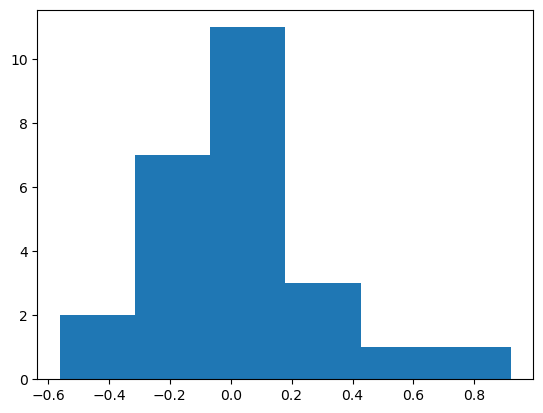

In [472]:
fig, ax = plt.subplots()

ax.hist(errors, bins=6)

In [475]:
np.nanmedian(errors)

np.float64(0.030583652006970278)

Text(0.5, 1.0, '2021-05-10')

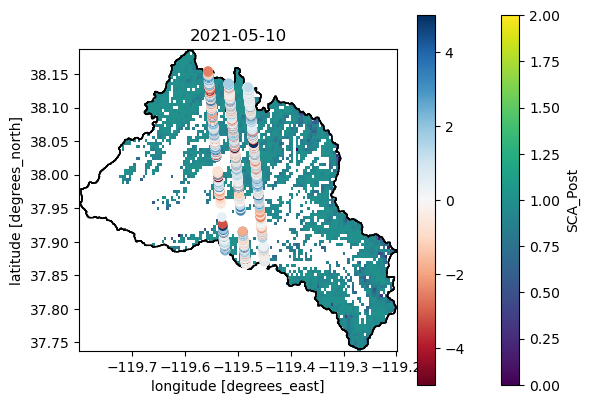

In [261]:
reanalysis_fsca = fsca_reanalysis_clipped_2019[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
is2 = atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326')
is2['fsca_reanalysis'] = 

fig, ax = plt.subplots()
reanalysis_fsca.where(reanalysis_test>0.1).plot(ax=ax, vmax=2)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

make a subset of the icesat2 data based on the date. Then sample the fsca data array at each point, and use that column as a conditional of whether to include the icesat-2 point in the plots and median values.

In [374]:
date_index =0

In [373]:
snowon_dates[0]

datetime.date(2018, 12, 11)

In [375]:
snowon_dates[date_index]

datetime.date(2018, 12, 11)

In [371]:
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[0])]

,distance,h_sigma,rgt,delta_time,pflags,dh_fit_dy,segment_id,w_surface_window_final,dh_fit_dx,h_mean,...,acqdate,n,diff_plus,diff_plus_bicubic,zscore,ASO_snowon,ASO_snowon_date,ASO_snowon_bic,median_slope20d,reanalysis_fsca
time,,,,,,,,,,,,,,,,,,,,,
2018-12-11 08:53:00.121753424,1.582237e+07,0.046549,1126,2.975358e+07,0,0.0,789953,3.000000,0.054320,3142.654622,...,2018-12-11,6215,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.9544
2018-12-11 08:53:00.124567280,1.582239e+07,0.072951,1126,2.975358e+07,0,0.0,789954,3.088237,0.118709,3144.413626,...,2018-12-11,6215,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.9544
2018-12-11 08:53:00.130217820,1.582243e+07,0.107678,1126,2.975358e+07,0,0.0,789956,3.000000,-0.107540,3143.755805,...,2018-12-11,6215,1.177227,1.230901,0.435510,NaN,NaN,NaN,NaN,0.9544
2018-12-11 08:53:00.133047480,1.582245e+07,0.104155,1126,2.975358e+07,0,0.0,789957,3.069950,-0.117977,3141.496978,...,2018-12-11,6215,0.268497,0.510397,0.014922,NaN,NaN,NaN,NaN,0.9544
2018-12-11 08:53:00.150044280,1.582257e+07,0.174431,1126,2.975358e+07,0,0.0,789963,12.856402,-0.503602,3109.734898,...,2018-12-11,6215,0.268380,-0.621090,-0.645575,NaN,NaN,NaN,25.544275,0.9544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-11 08:53:05.148196040,1.585570e+07,0.029269,1126,2.975359e+07,0,0.0,791616,7.409657,0.289583,2515.233253,...,2018-12-11,6215,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-12-11 08:53:05.150989896,1.585572e+07,0.050507,1126,2.975359e+07,0,0.0,791617,9.368451,0.366607,2521.917236,...,2018-12-11,6215,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-12-11 08:53:05.153783736,1.585574e+07,0.047248,1126,2.975359e+07,0,0.0,791618,11.032542,0.431983,2530.107320,...,2018-12-11,6215,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [378]:
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']

time
2018-12-11 08:53:00.121753424         NaN
2018-12-11 08:53:00.124567280         NaN
2018-12-11 08:53:00.130217820    1.230901
2018-12-11 08:53:00.133047480    0.510397
2018-12-11 08:53:00.150044280   -0.621090
                                   ...   
2018-12-11 08:53:05.108532540   -0.207285
2018-12-11 08:53:05.111348520    0.486198
2018-12-11 08:53:05.114172264    0.782454
2018-12-11 08:53:05.117008848         NaN
2018-12-11 08:53:05.119862496         NaN
Name: diff_plus_bicubic, Length: 5592, dtype: float64

In [367]:
snowon_dates[0]

datetime.date(2018, 12, 11)

Text(0.5, 1.0, '2018-12-11')

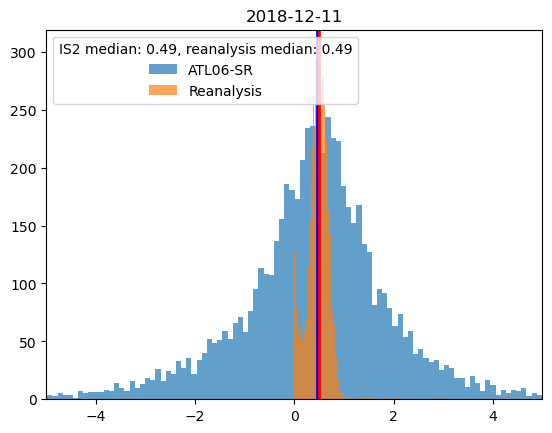

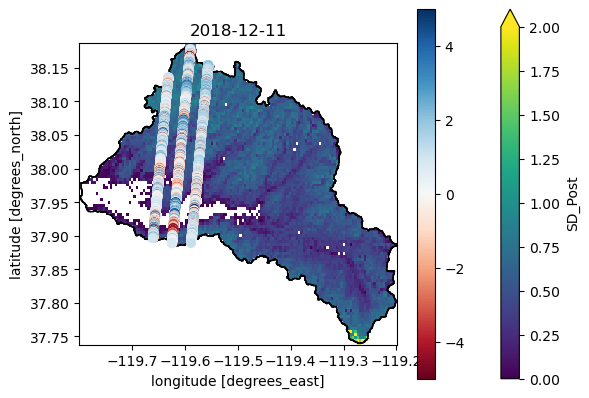

In [415]:
date_index = 0

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2019[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2019[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 5)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=2)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

# print('IS2 median: ', np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']))
# print('Reanalysis median: ',np.nanmedian(reanalysis_test.where(reanalysis_test>0.1).values.flatten()))

Text(0.5, 1.0, '2018-12-11')

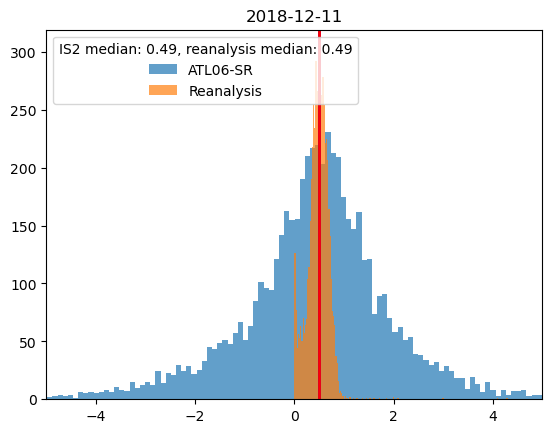

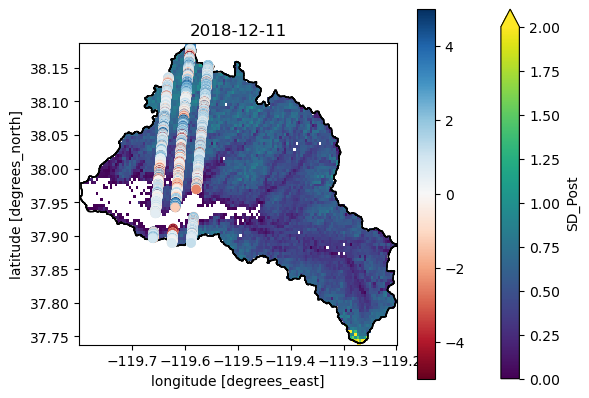

In [413]:
date_index = 0

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2019[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2019[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 5)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=2)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

# print('IS2 median: ', np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']))
# print('Reanalysis median: ',np.nanmedian(reanalysis_test.where(reanalysis_test>0.1).values.flatten()))

Text(0.5, 1.0, '2019-01-09')

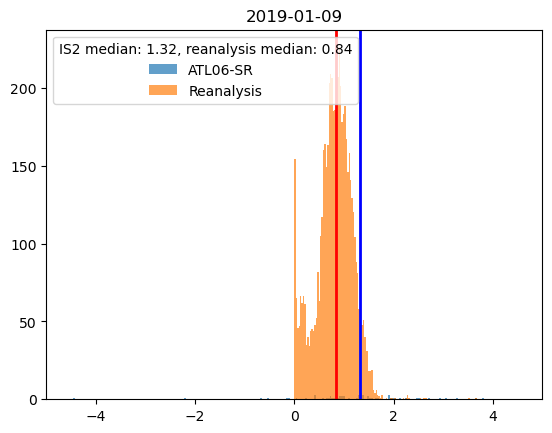

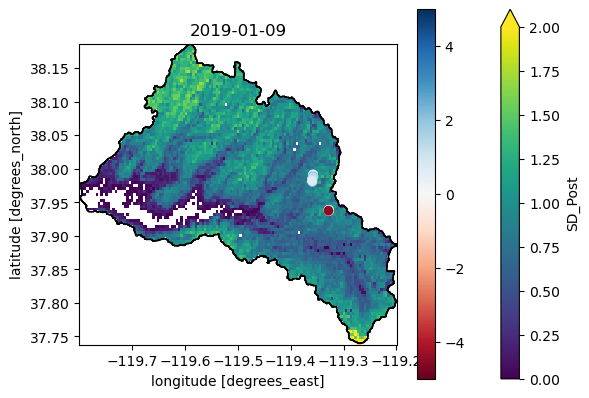

In [414]:
date_index = 1

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2019[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2019[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 5)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=2)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

Text(0.5, 1.0, '2019-01-09')

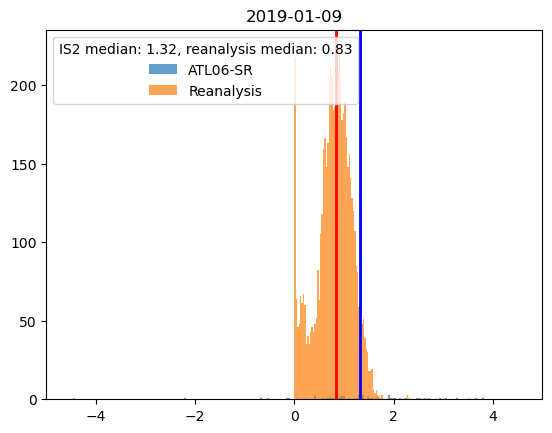

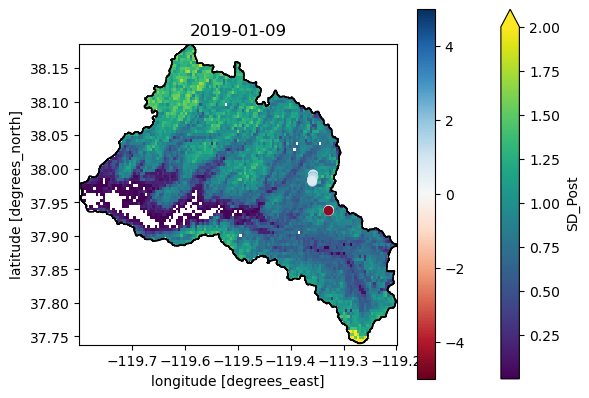

In [220]:
date_index = 1

reanalysis_test = reanalysis_clipped_2019[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_test>0).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 5)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()):.2f}')

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_test>0).plot(ax=ax, vmax=2)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

# print('IS2 median: ', np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']))
# print('Reanalysis median: ',np.nanmedian(reanalysis_test.where(reanalysis_test>0.1).values.flatten()))

Text(0.5, 1.0, '2019-03-12')

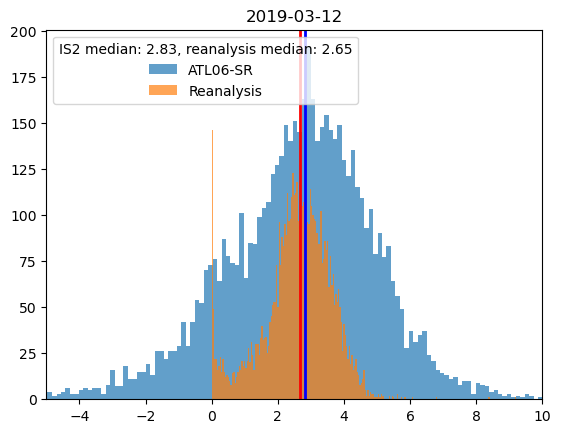

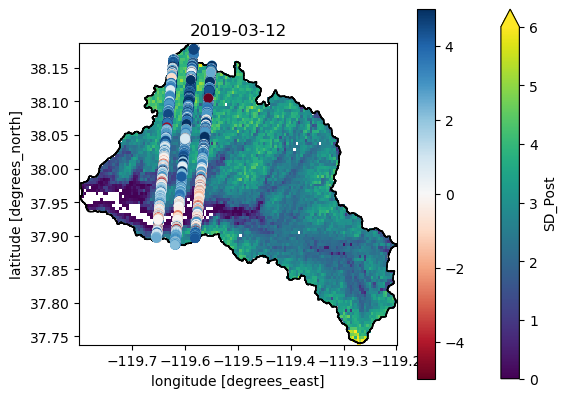

In [383]:
date_index = 2

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2019[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2019[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

Text(0.5, 1.0, '2019-03-12')

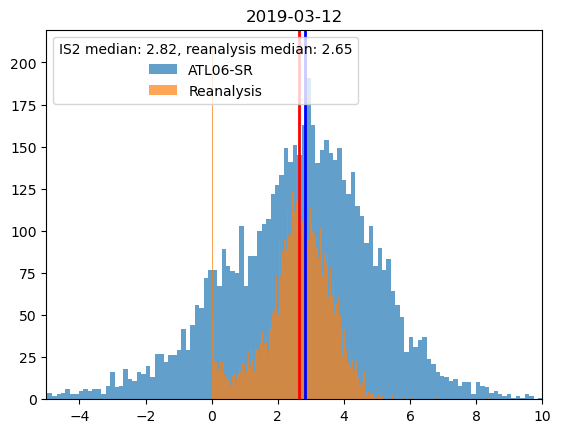

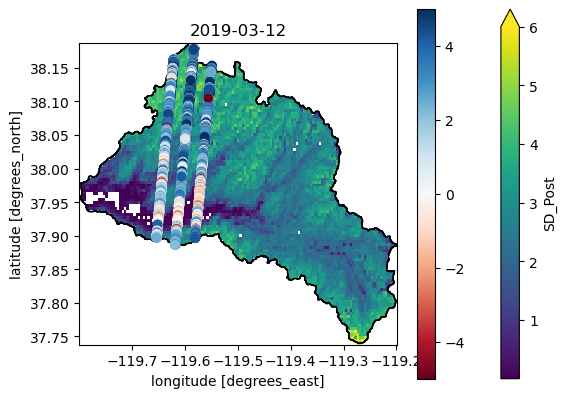

In [223]:
date_index = 2

reanalysis_test = reanalysis_clipped_2019[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_test>0).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()):.2f}')

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_test>0).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

# print('IS2 median: ', np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']))
# print('Reanalysis median: ',np.nanmedian(reanalysis_test.where(reanalysis_test>0.1).values.flatten()))

Text(0.5, 1.0, '2019-04-10')

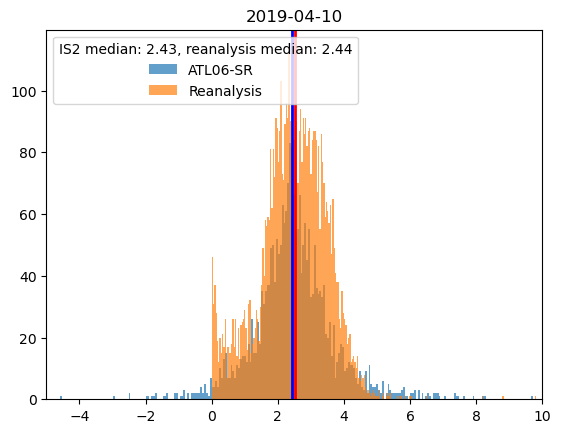

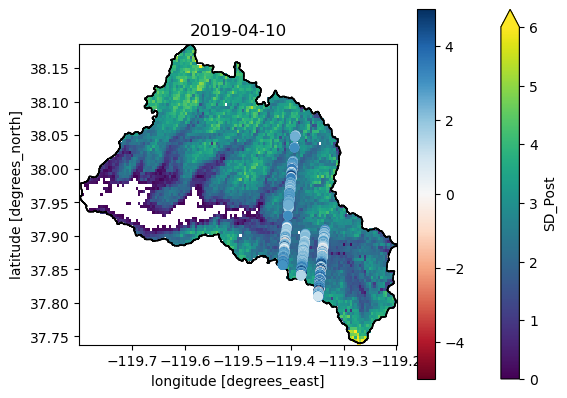

In [385]:
date_index = 3

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2019[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2019[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

Text(0.5, 1.0, '2019-04-10')

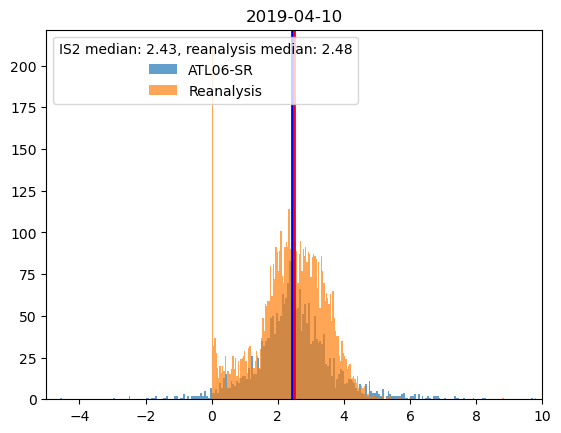

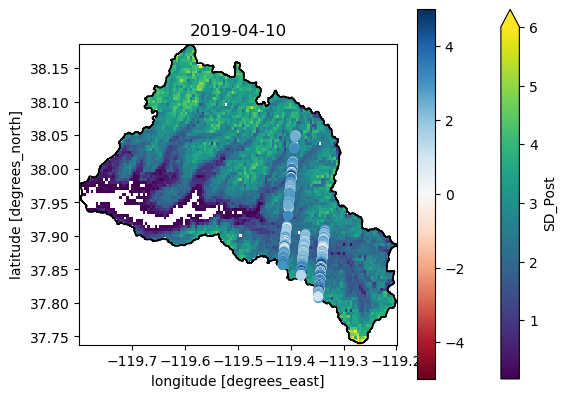

In [224]:
date_index = 3

reanalysis_test = reanalysis_clipped_2019[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_test>0).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()):.2f}')

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_test>0).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

# print('IS2 median: ', np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']))
# print('Reanalysis median: ',np.nanmedian(reanalysis_test.where(reanalysis_test>0.1).values.flatten()))

Text(0.5, 1.0, '2019-05-14')

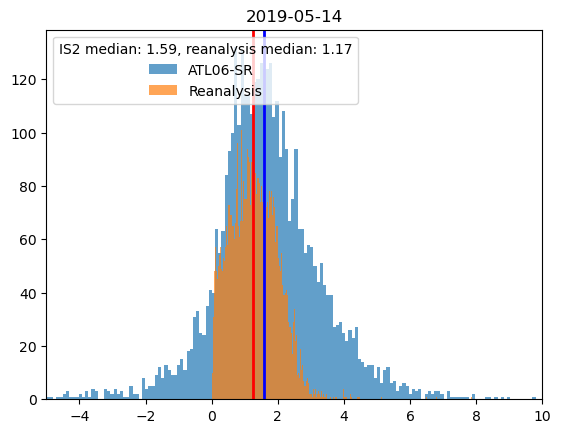

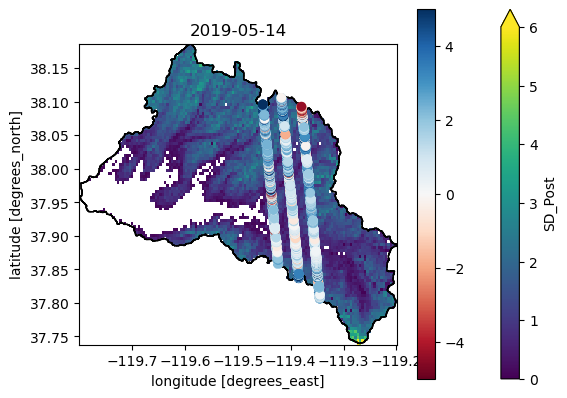

In [386]:
date_index = 4

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2019[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2019[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

Text(0.5, 1.0, '2019-05-14')

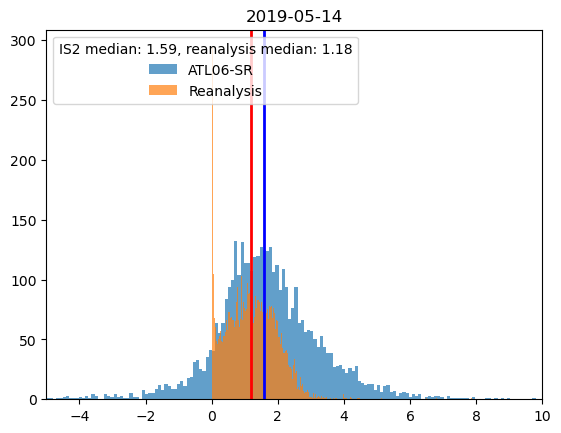

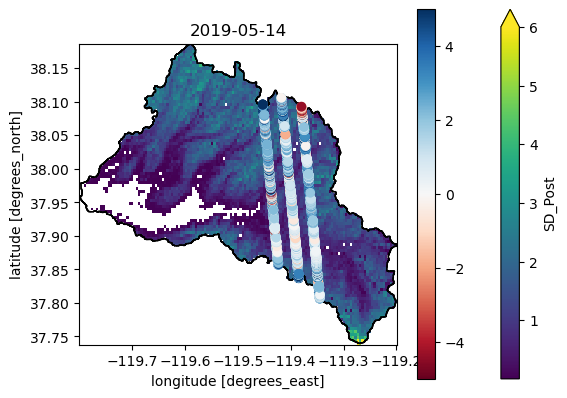

In [225]:
date_index = 4

reanalysis_test = reanalysis_clipped_2019[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_test>0).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()):.2f}')

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_test>0).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

# print('IS2 median: ', np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']))
# print('Reanalysis median: ',np.nanmedian(reanalysis_test.where(reanalysis_test>0.1).values.flatten()))

### Water Year 2020:

Text(0.5, 1.0, '2019-12-09')

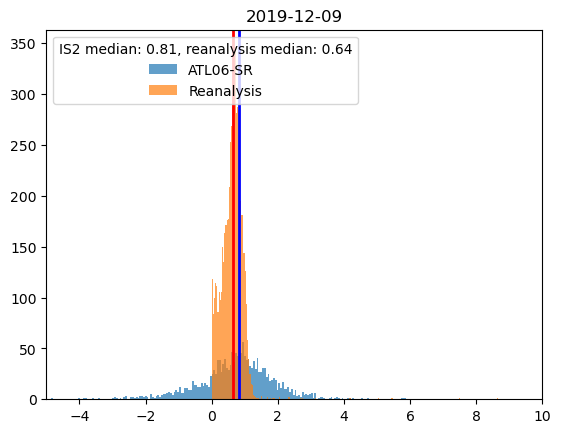

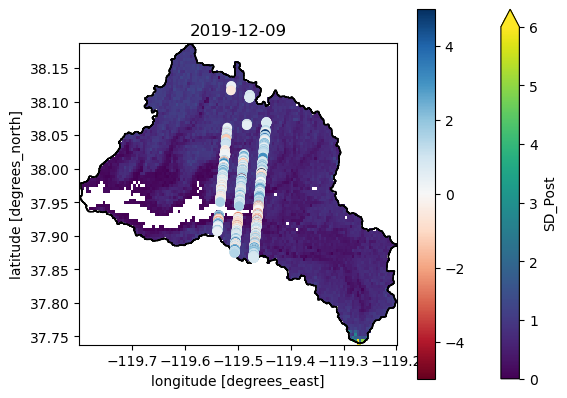

In [387]:
date_index = 5

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

Text(0.5, 1.0, '2019-12-09')

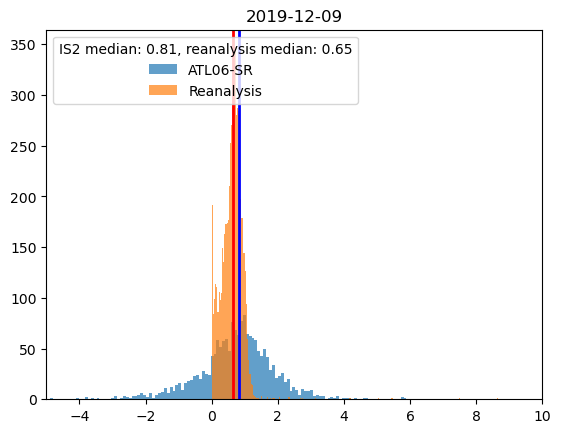

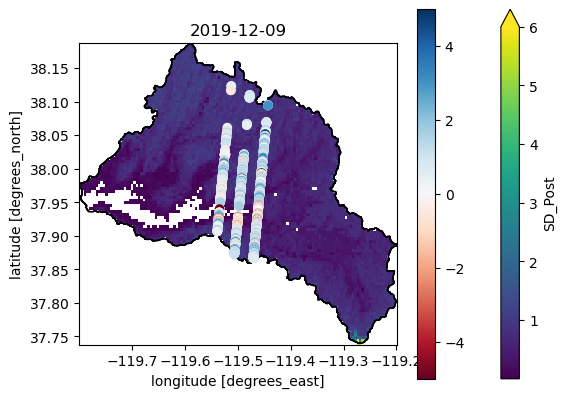

In [388]:
date_index = 5

reanalysis_test = reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_test>0).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()):.2f}')

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_test>0).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

# print('IS2 median: ', np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']))
# print('Reanalysis median: ',np.nanmedian(reanalysis_test.where(reanalysis_test>0.1).values.flatten()))

Text(0.5, 1.0, '2019-12-11')

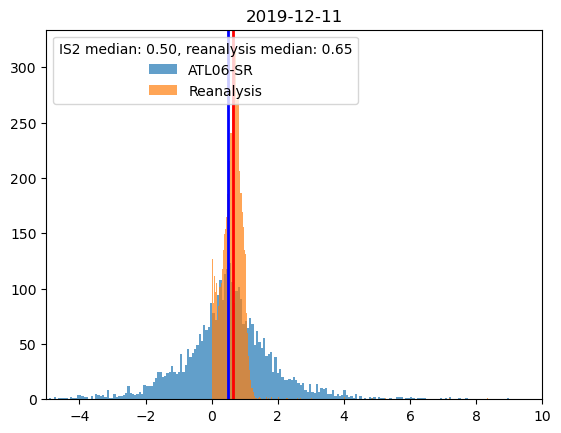

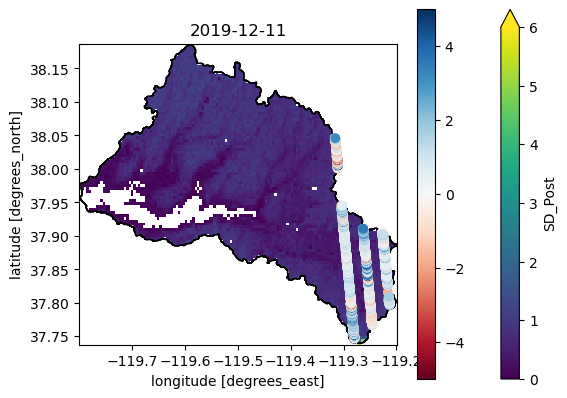

In [389]:
date_index = 6

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

Text(0.5, 1.0, '2019-12-11')

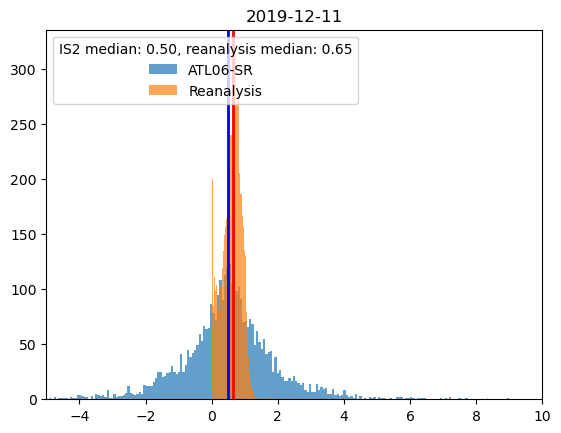

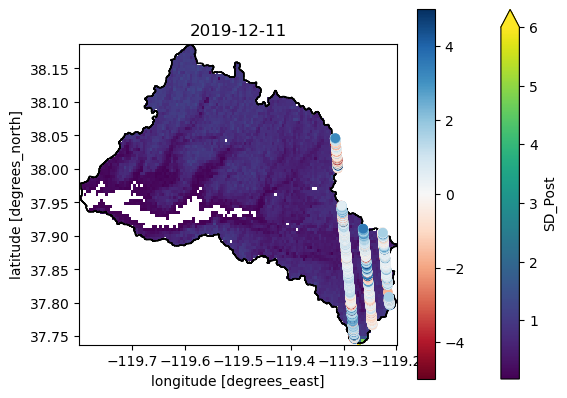

In [227]:
date_index = 6

reanalysis_test = reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_test>0).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()):.2f}')

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_test>0).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

# print('IS2 median: ', np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']))
# print('Reanalysis median: ',np.nanmedian(reanalysis_test.where(reanalysis_test>0.1).values.flatten()))

Text(0.5, 1.0, '2020-01-07')

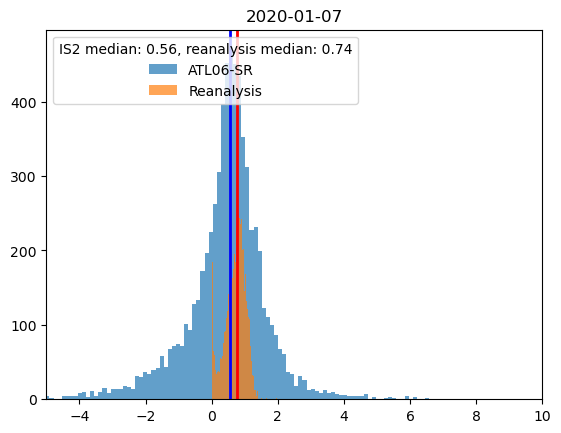

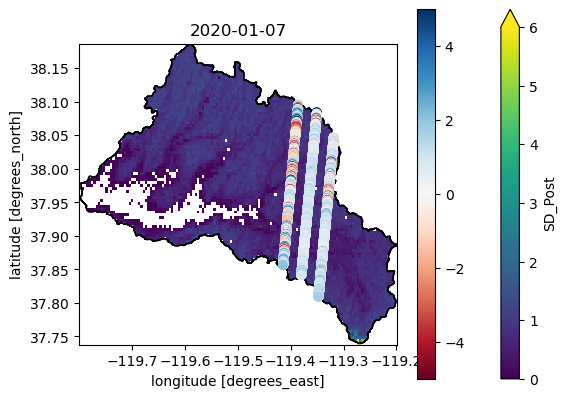

In [390]:
date_index = 7

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

Text(0.5, 1.0, '2020-01-07')

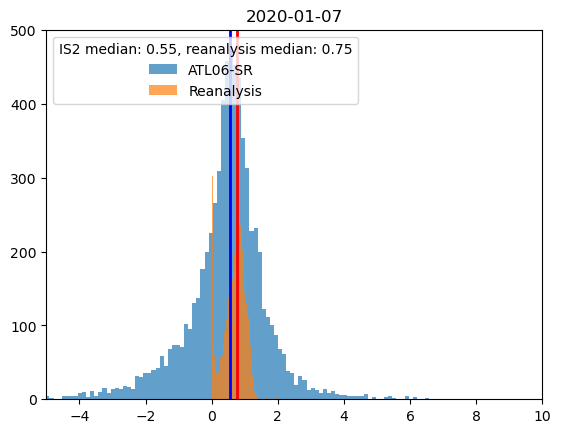

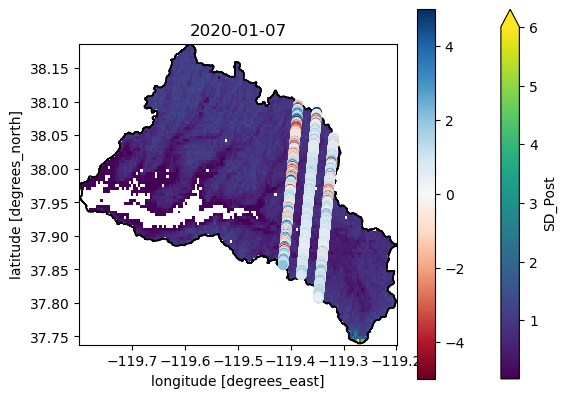

In [228]:
date_index = 7

reanalysis_test = reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_test>0).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()):.2f}')

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_test>0).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

# print('IS2 median: ', np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']))
# print('Reanalysis median: ',np.nanmedian(reanalysis_test.where(reanalysis_test>0.1).values.flatten()))

Text(0.5, 1.0, '2020-01-13')

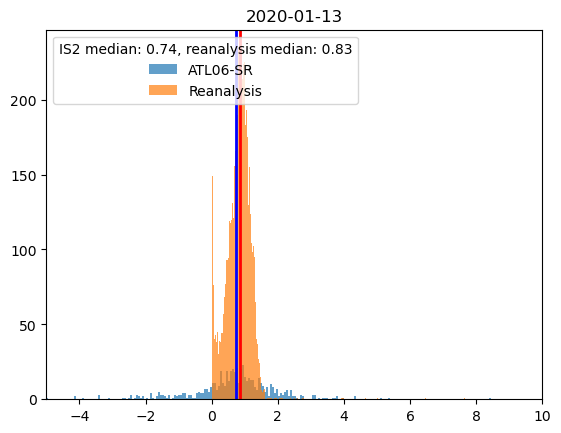

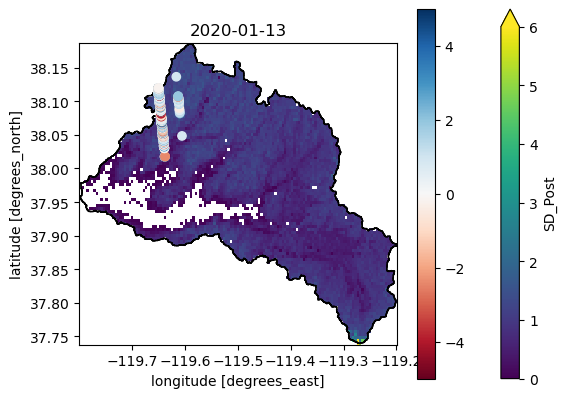

In [391]:
date_index = 8

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

Text(0.5, 1.0, '2020-01-13')

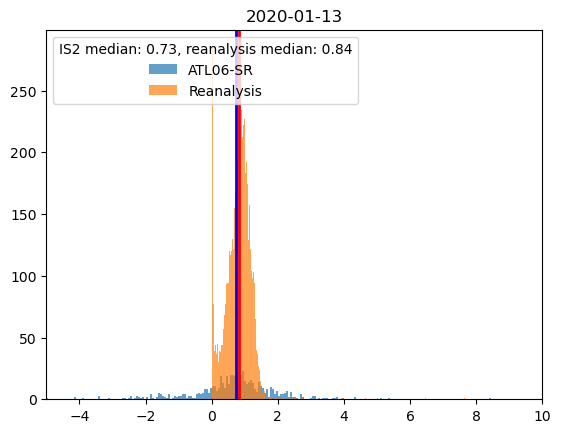

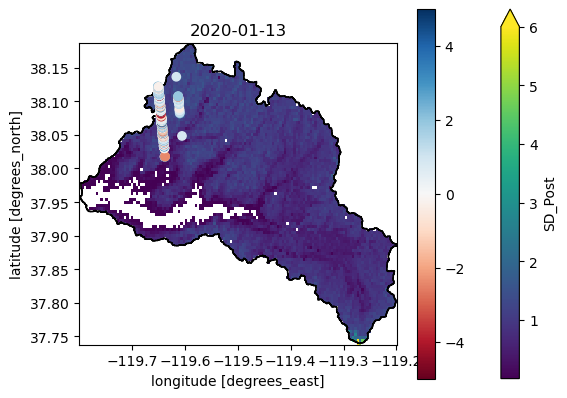

In [229]:
date_index = 8

reanalysis_test = reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_test>0).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()):.2f}')

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_test>0).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

# print('IS2 median: ', np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']))
# print('Reanalysis median: ',np.nanmedian(reanalysis_test.where(reanalysis_test>0.1).values.flatten()))

Text(0.5, 1.0, '2020-02-05')

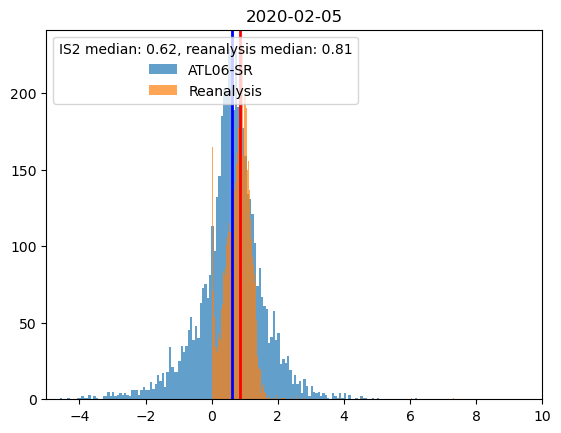

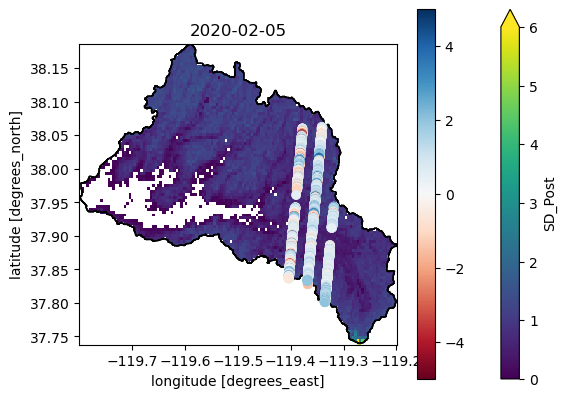

In [392]:
date_index = 9

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

Text(0.5, 1.0, '2020-02-05')

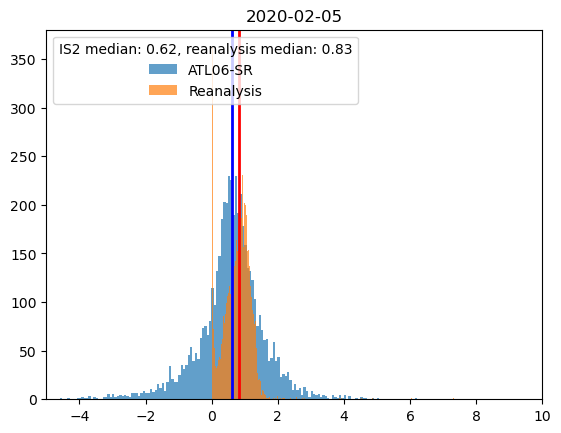

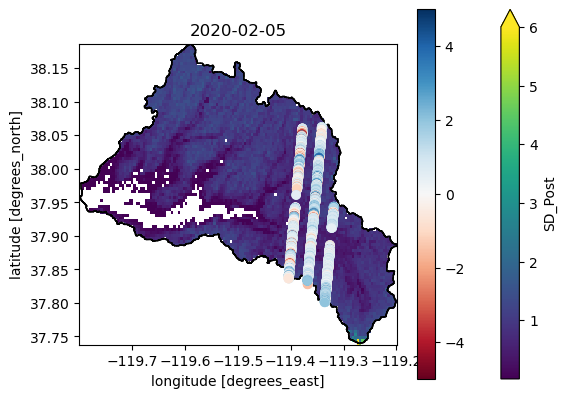

In [230]:
date_index = 9

reanalysis_test = reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_test>0).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()):.2f}')

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_test>0).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

# print('IS2 median: ', np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']))
# print('Reanalysis median: ',np.nanmedian(reanalysis_test.where(reanalysis_test>0.1).values.flatten()))

Text(0.5, 1.0, '2020-02-11')

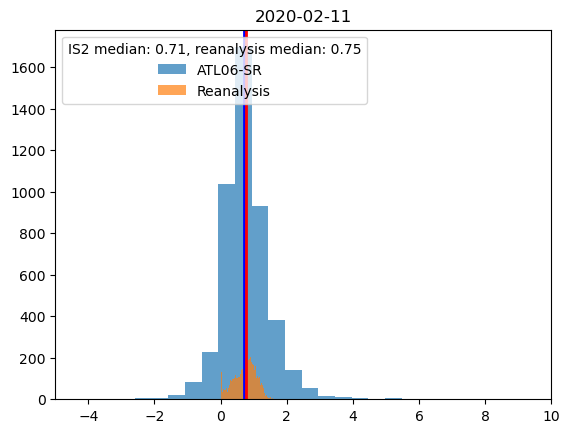

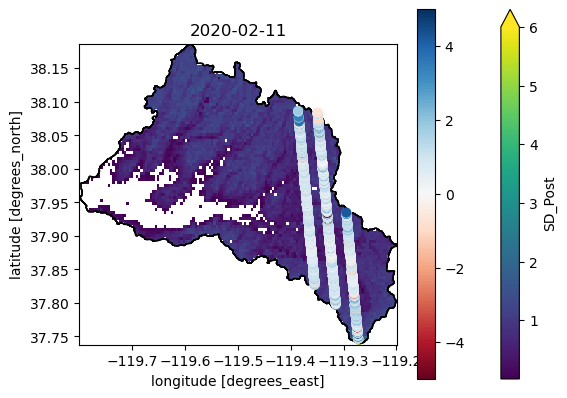

In [393]:
date_index = 10

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

Text(0.5, 1.0, '2020-02-11')

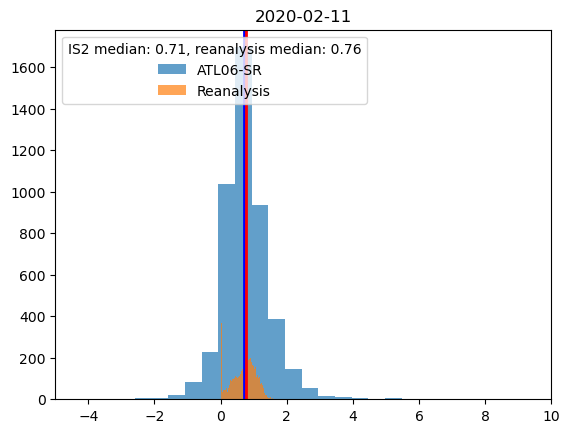

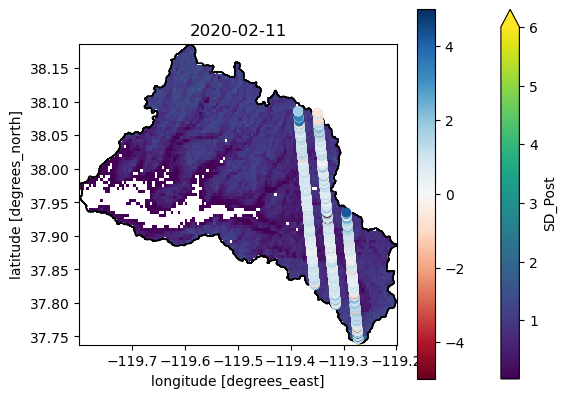

In [231]:
date_index = 10

reanalysis_test = reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_test>0).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()):.2f}')

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_test>0).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

# print('IS2 median: ', np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']))
# print('Reanalysis median: ',np.nanmedian(reanalysis_test.where(reanalysis_test>0.1).values.flatten()))

Text(0.5, 1.0, '2020-03-09')

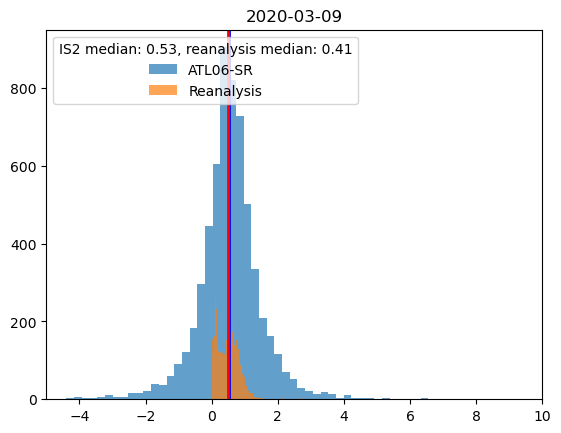

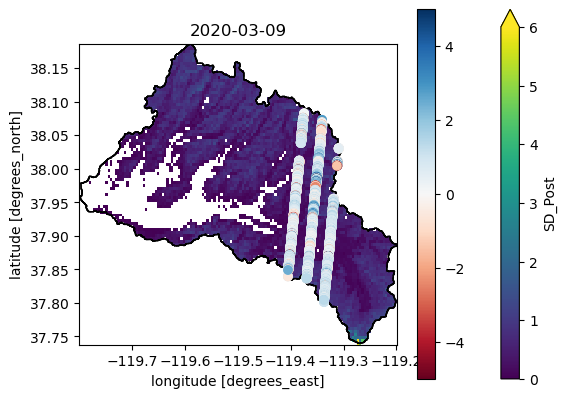

In [394]:
date_index = 11

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

Text(0.5, 1.0, '2020-03-09')

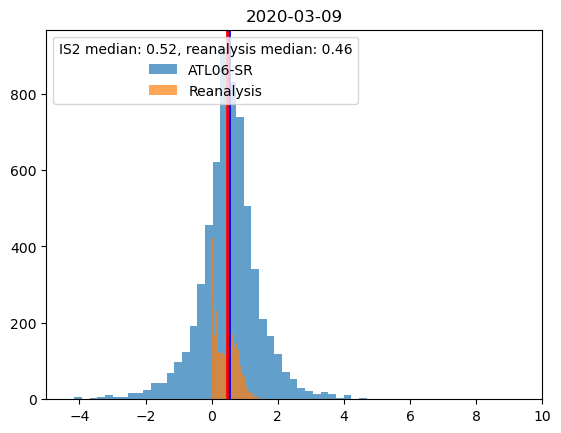

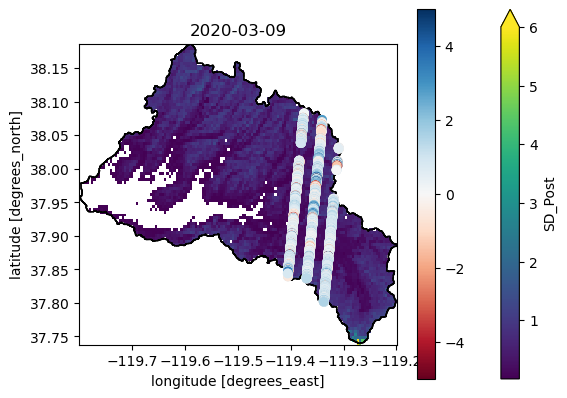

In [232]:
date_index = 11

reanalysis_test = reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_test>0).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()):.2f}')

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_test>0).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

# print('IS2 median: ', np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']))
# print('Reanalysis median: ',np.nanmedian(reanalysis_test.where(reanalysis_test>0.1).values.flatten()))

Text(0.5, 1.0, '2020-03-10')

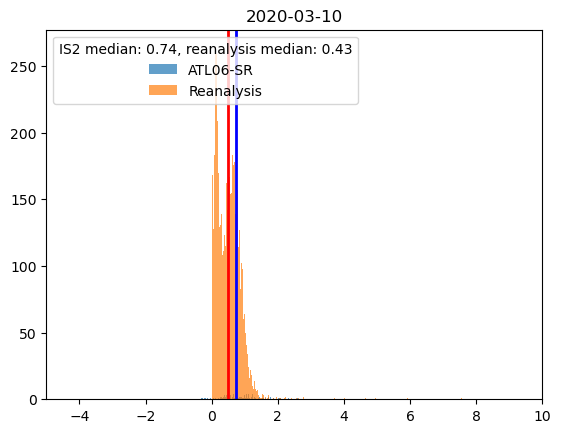

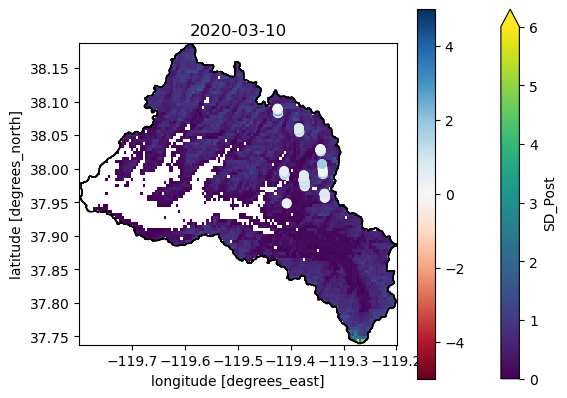

In [395]:
date_index = 12

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

Text(0.5, 1.0, '2020-03-10')

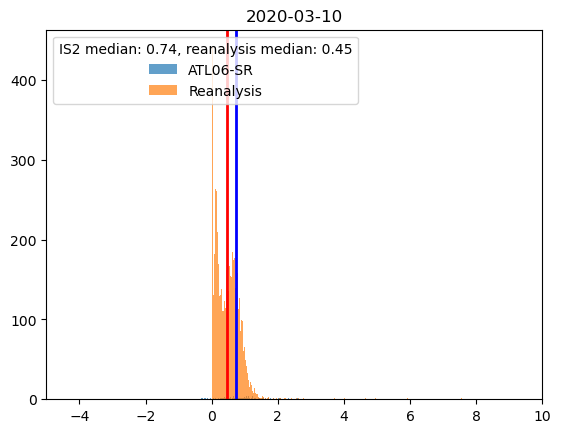

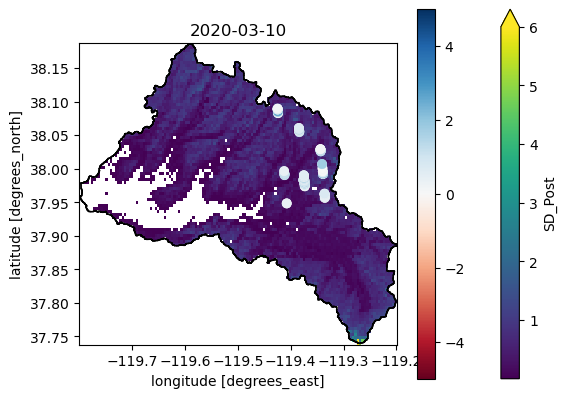

In [233]:
date_index = 12

reanalysis_test = reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_test>0).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()):.2f}')

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_test>0).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

# print('IS2 median: ', np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']))
# print('Reanalysis median: ',np.nanmedian(reanalysis_test.where(reanalysis_test>0.1).values.flatten()))

Text(0.5, 1.0, '2020-04-07')

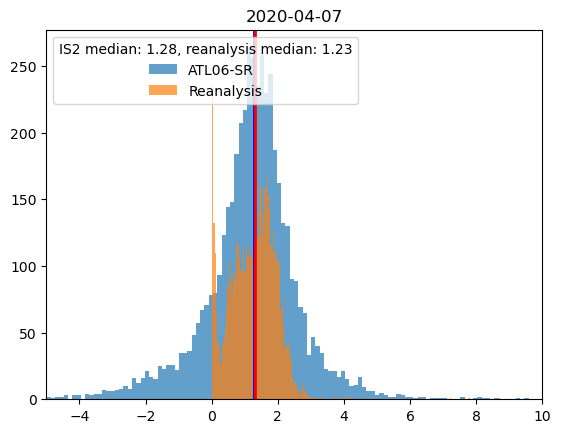

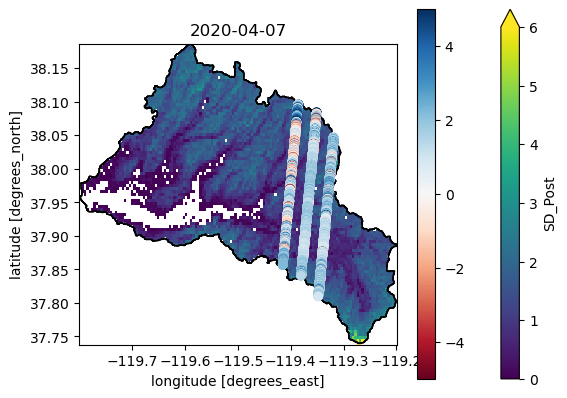

In [396]:
date_index = 13

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

Text(0.5, 1.0, '2020-04-07')

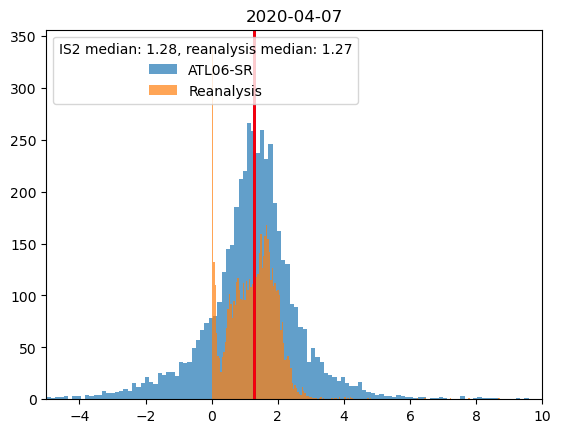

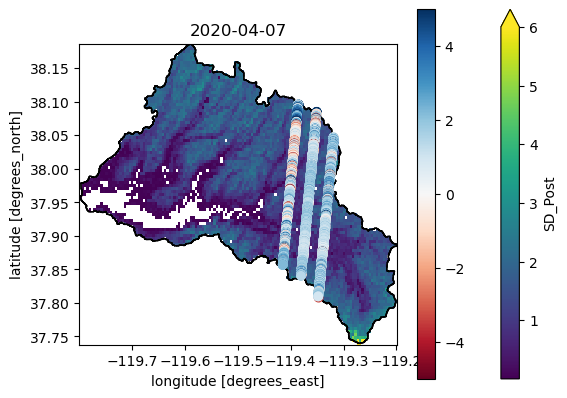

In [234]:
date_index = 13

reanalysis_test = reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_test>0).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()):.2f}')

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_test>0).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

# print('IS2 median: ', np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']))
# print('Reanalysis median: ',np.nanmedian(reanalysis_test.where(reanalysis_test>0.1).values.flatten()))

Text(0.5, 1.0, '2020-04-12')

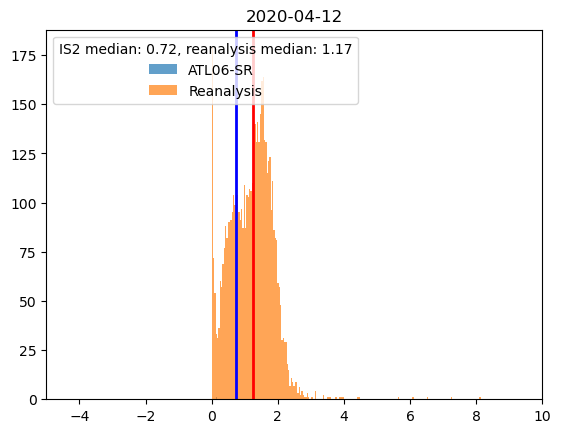

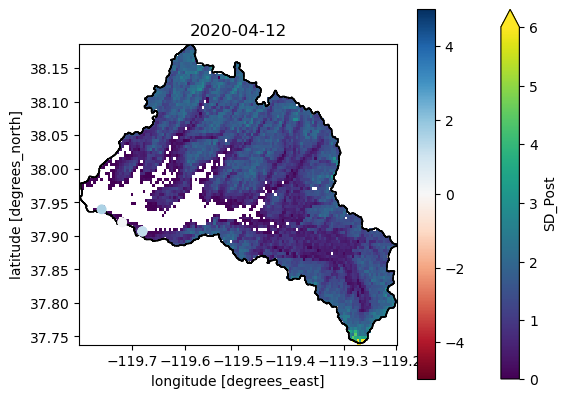

In [397]:
date_index = 14

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

Text(0.5, 1.0, '2020-04-12')

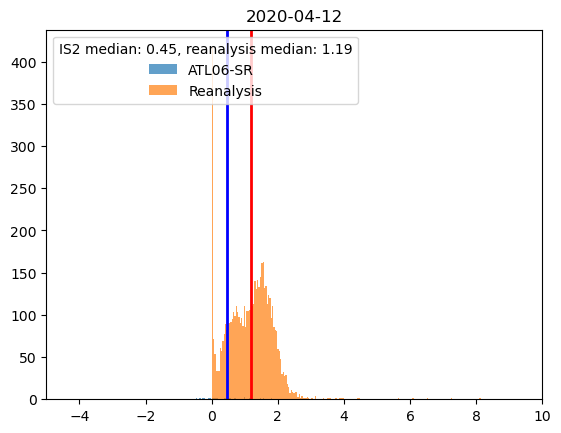

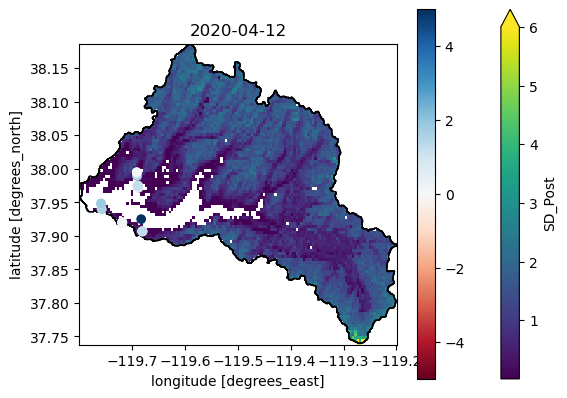

In [235]:
date_index = 14

reanalysis_test = reanalysis_clipped_2020[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_test>0).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()):.2f}')

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_test>0).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

# print('IS2 median: ', np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']))
# print('Reanalysis median: ',np.nanmedian(reanalysis_test.where(reanalysis_test>0.1).values.flatten()))

### Water Year 2021:

Text(0.5, 1.0, '2020-12-06')

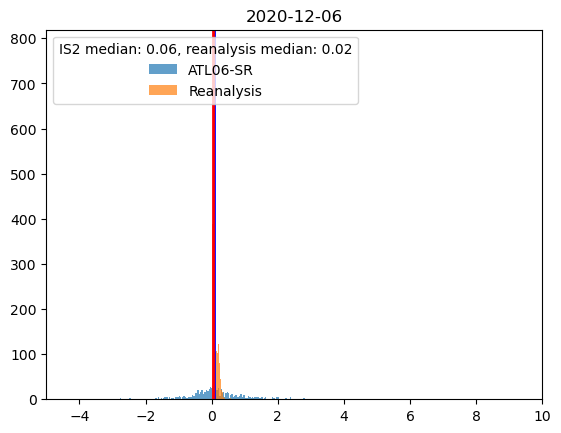

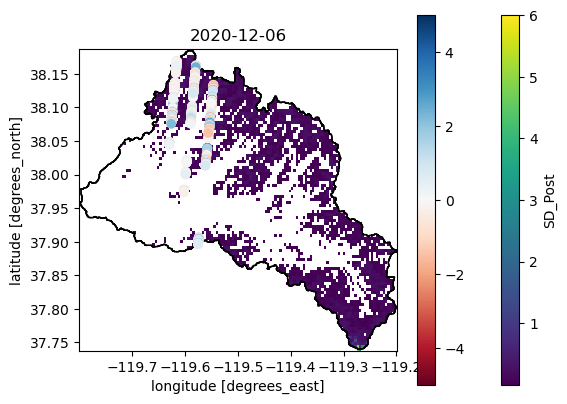

In [398]:
date_index = 15

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

Text(0.5, 1.0, '2020-12-06')

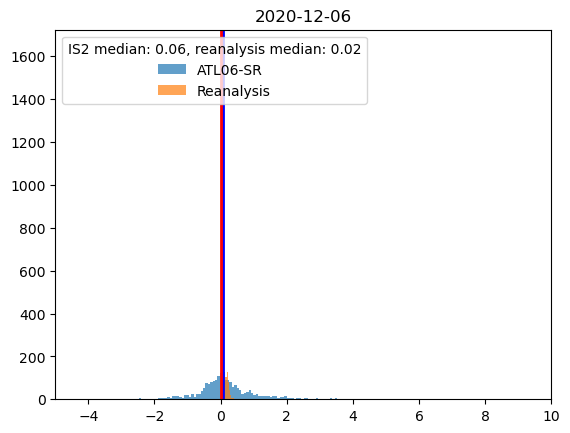

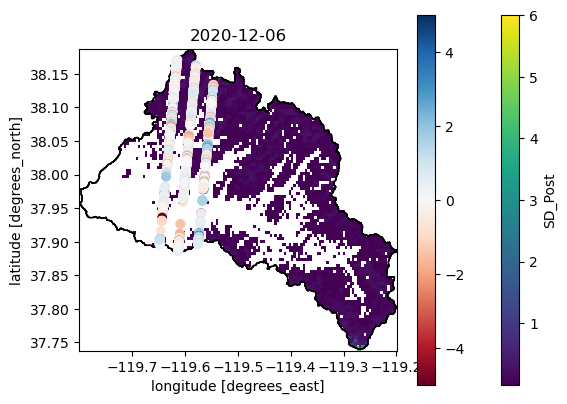

In [236]:
date_index = 15

reanalysis_test = reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_test>0).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()):.2f}')

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_test>0).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

# print('IS2 median: ', np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']))
# print('Reanalysis median: ',np.nanmedian(reanalysis_test.where(reanalysis_test>0.1).values.flatten()))

Text(0.5, 1.0, '2020-12-08')

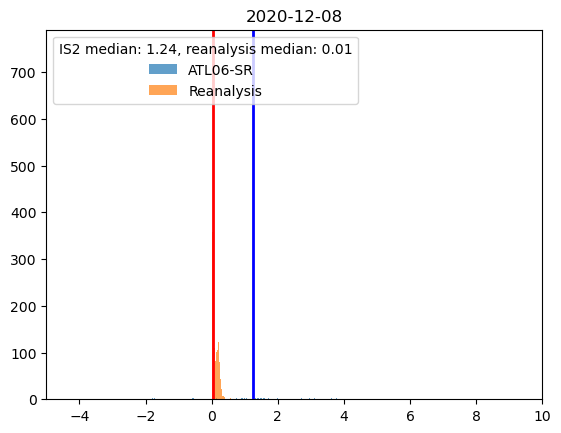

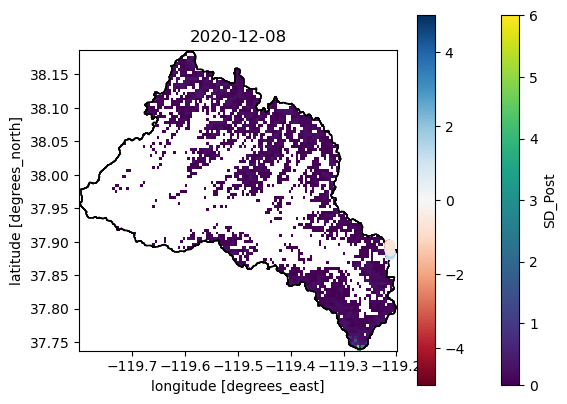

In [399]:
date_index = 16

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

Text(0.5, 1.0, '2020-12-08')

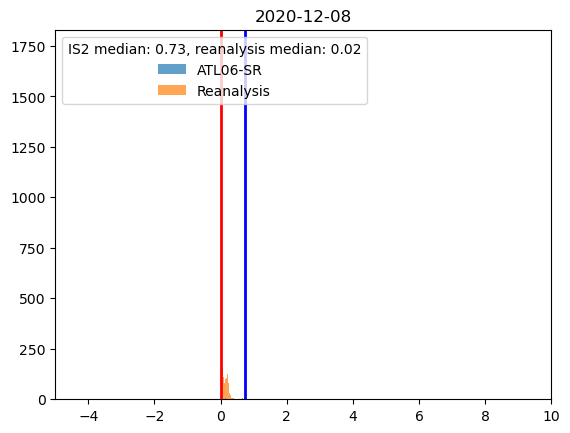

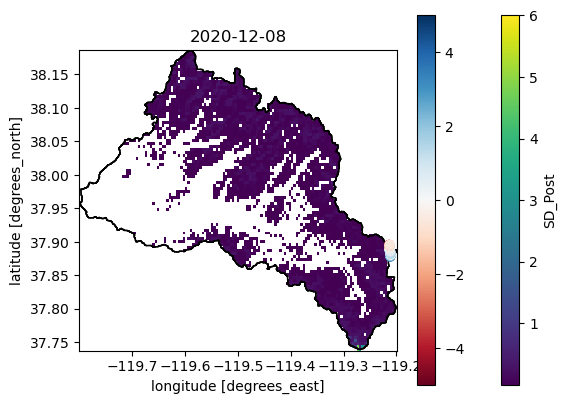

In [237]:
date_index = 16

reanalysis_test = reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_test>0).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()):.2f}')

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_test>0).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

# print('IS2 median: ', np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']))
# print('Reanalysis median: ',np.nanmedian(reanalysis_test.where(reanalysis_test>0.1).values.flatten()))

Text(0.5, 1.0, '2021-01-10')

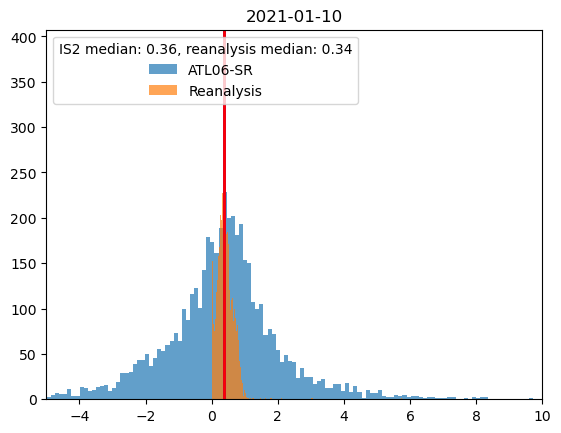

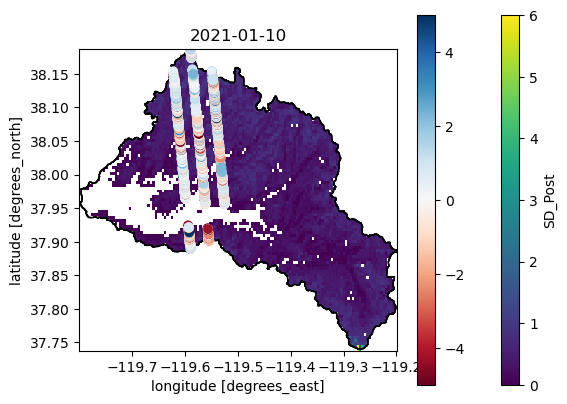

In [400]:
date_index = 17

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

Text(0.5, 1.0, '2021-01-10')

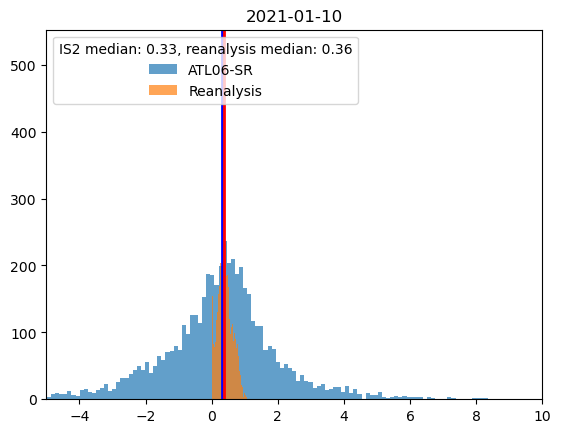

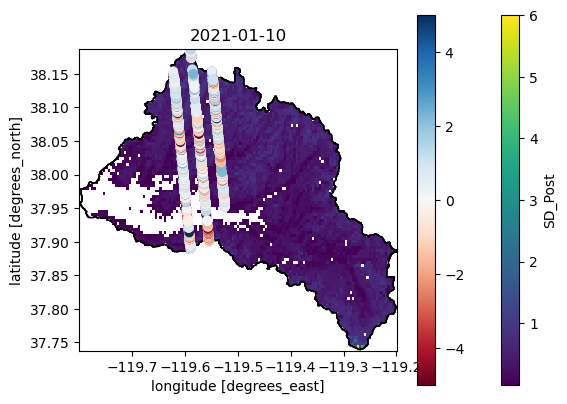

In [238]:
date_index = 17

reanalysis_test = reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_test>0).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()):.2f}')

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_test>0).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

# print('IS2 median: ', np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']))
# print('Reanalysis median: ',np.nanmedian(reanalysis_test.where(reanalysis_test>0.1).values.flatten()))

Text(0.5, 1.0, '2021-02-02')

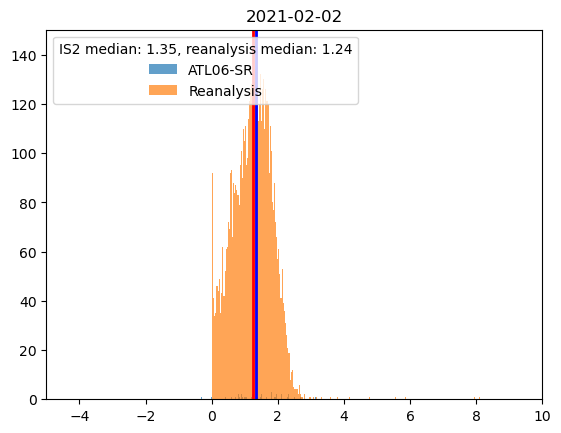

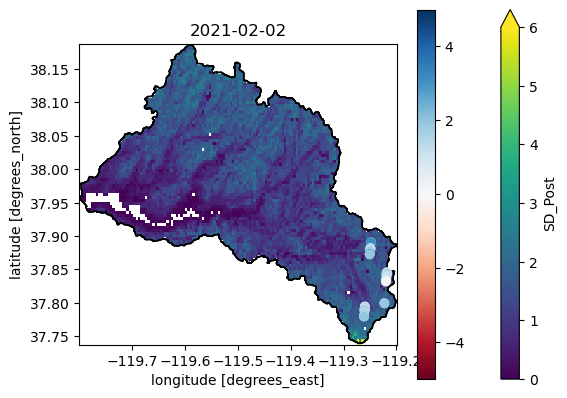

In [401]:
date_index = 18

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

Text(0.5, 1.0, '2021-02-02')

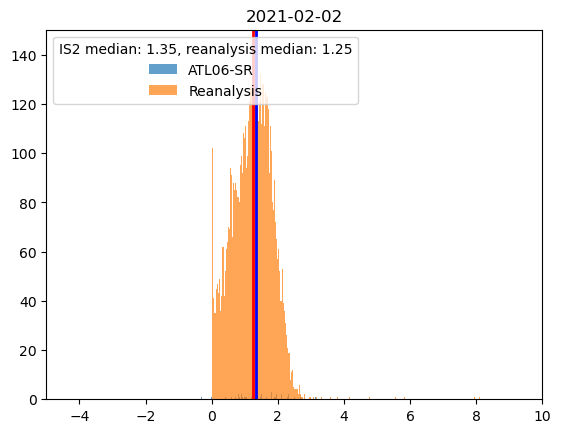

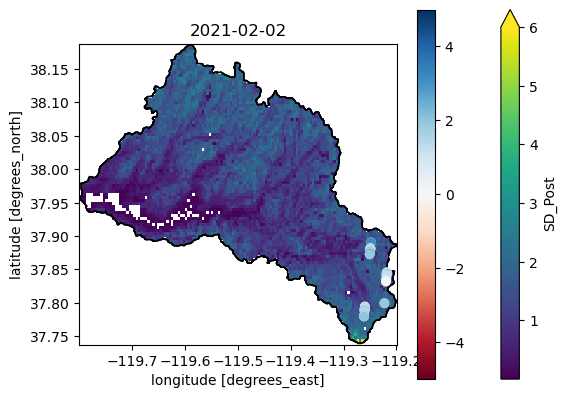

In [239]:
date_index = 18

reanalysis_test = reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_test>0).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()):.2f}')

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_test>0).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

# print('IS2 median: ', np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']))
# print('Reanalysis median: ',np.nanmedian(reanalysis_test.where(reanalysis_test>0.1).values.flatten()))

Text(0.5, 1.0, '2021-02-08')

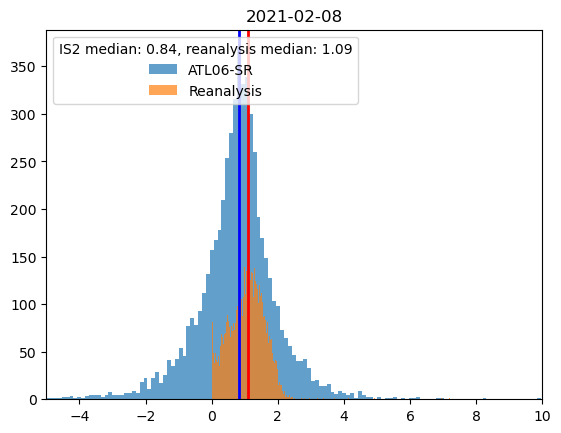

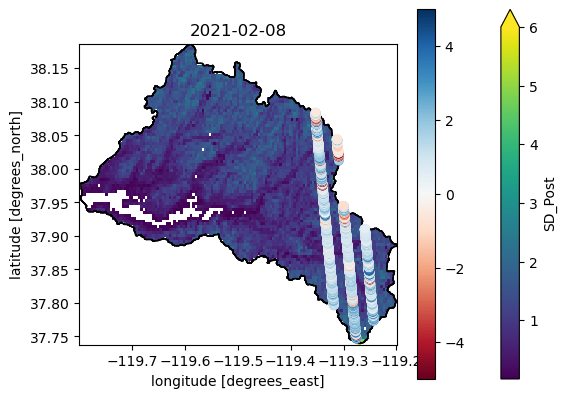

In [402]:
date_index = 19

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

Text(0.5, 1.0, '2021-02-08')

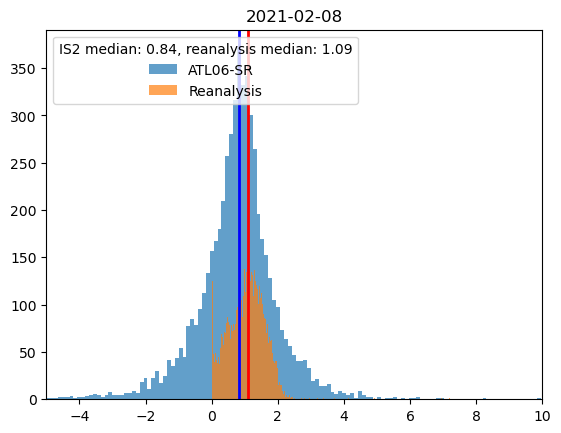

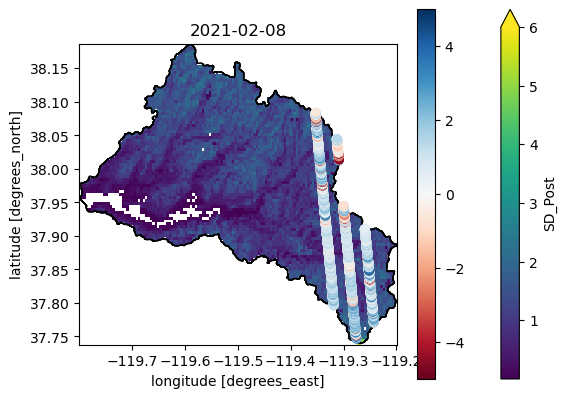

In [240]:
date_index = 19

reanalysis_test = reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_test>0).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()):.2f}')

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_test>0).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

# print('IS2 median: ', np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']))
# print('Reanalysis median: ',np.nanmedian(reanalysis_test.where(reanalysis_test>0.1).values.flatten()))

Text(0.5, 1.0, '2021-03-07')

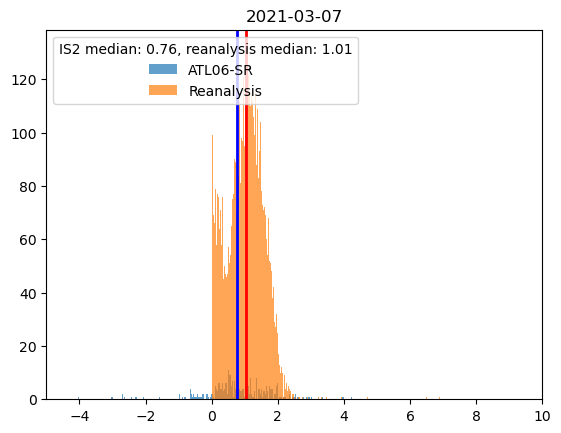

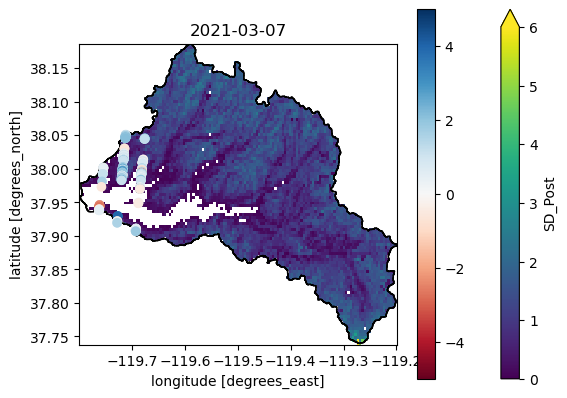

In [403]:
date_index = 20

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

Text(0.5, 1.0, '2021-03-07')

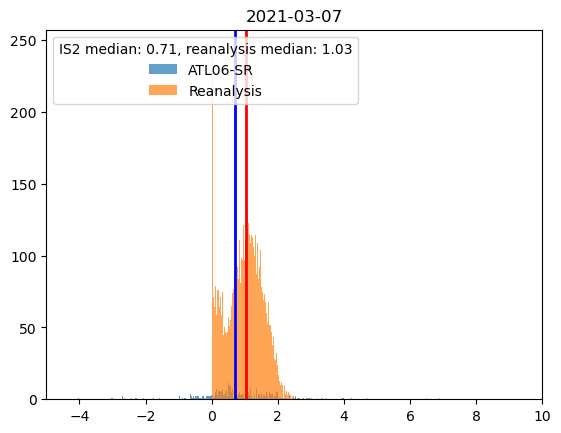

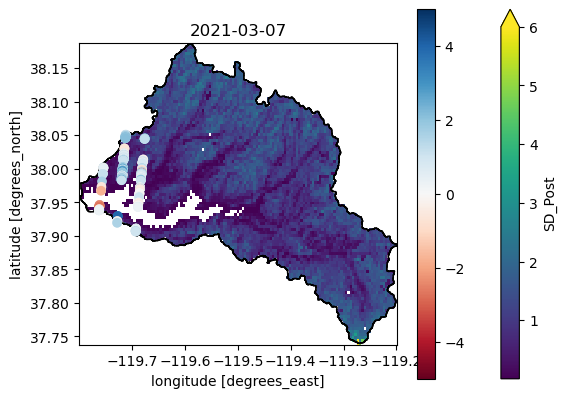

In [241]:
date_index = 20

reanalysis_test = reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_test>0).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()):.2f}')

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_test>0).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

# print('IS2 median: ', np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']))
# print('Reanalysis median: ',np.nanmedian(reanalysis_test.where(reanalysis_test>0.1).values.flatten()))

Text(0.5, 1.0, '2021-03-13')

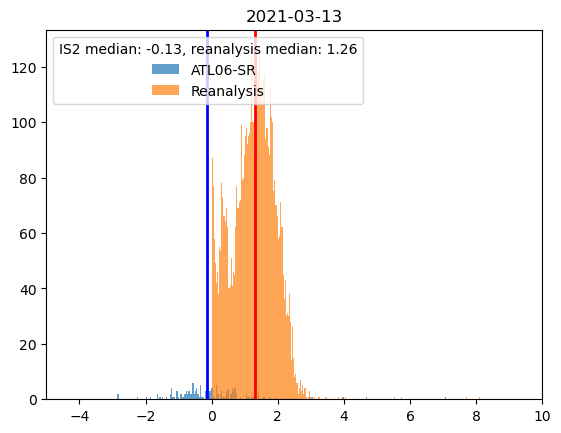

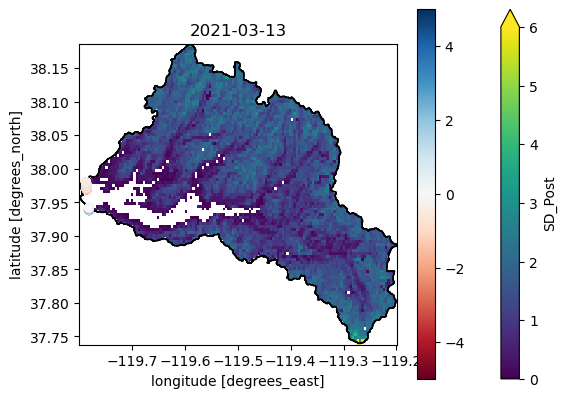

In [404]:
date_index = 21

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

Text(0.5, 1.0, '2021-03-13')

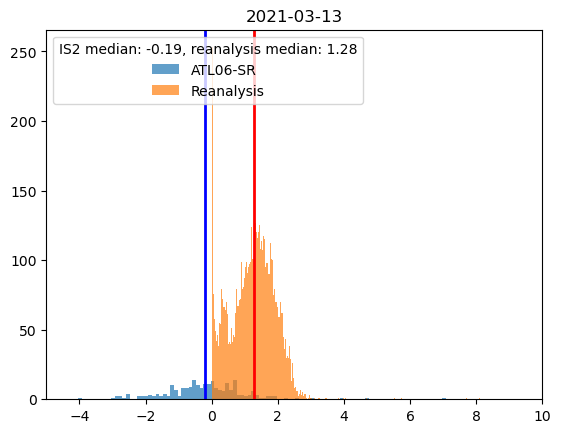

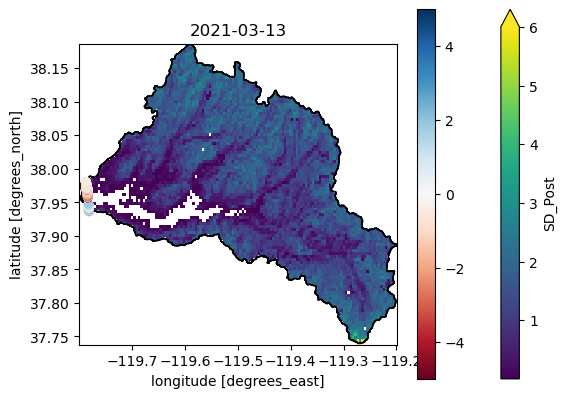

In [242]:
date_index = 21

reanalysis_test = reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_test>0).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()):.2f}')

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_test>0).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

# print('IS2 median: ', np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']))
# print('Reanalysis median: ',np.nanmedian(reanalysis_test.where(reanalysis_test>0.1).values.flatten()))

Text(0.5, 1.0, '2021-04-05')

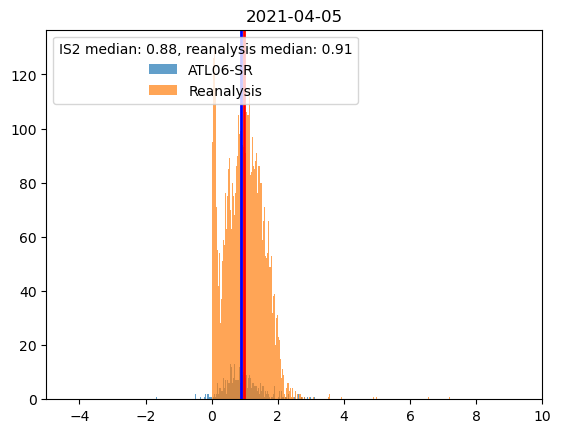

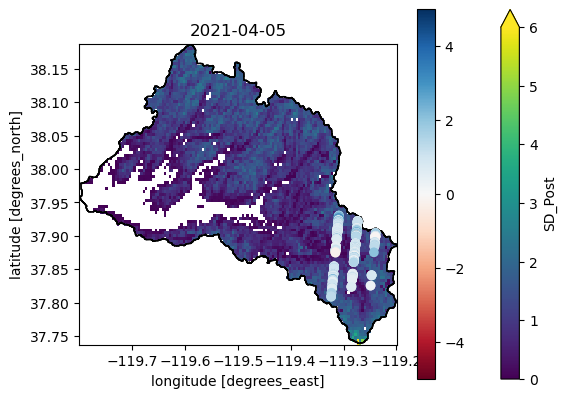

In [405]:
date_index = 22

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

Text(0.5, 1.0, '2021-04-05')

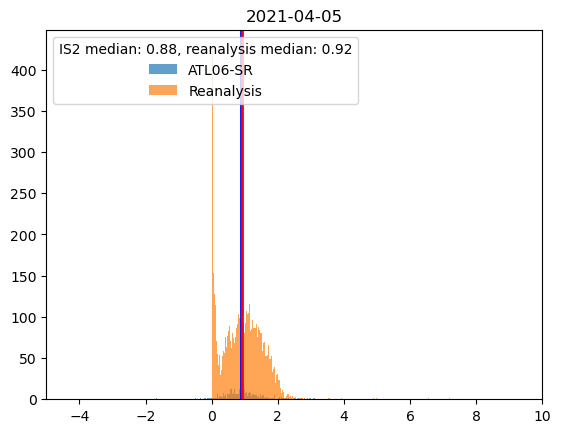

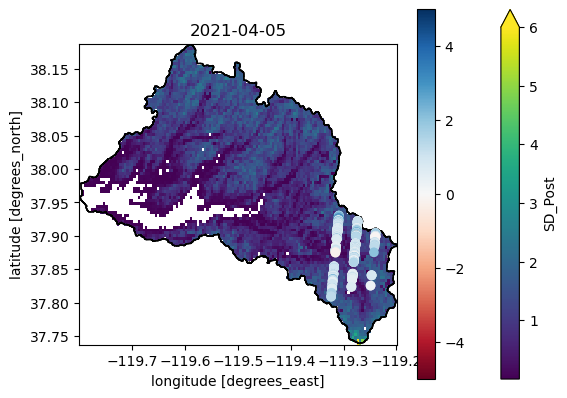

In [243]:
date_index = 22

reanalysis_test = reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_test>0).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()):.2f}')

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_test>0).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

# print('IS2 median: ', np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']))
# print('Reanalysis median: ',np.nanmedian(reanalysis_test.where(reanalysis_test>0.1).values.flatten()))

Text(0.5, 1.0, '2021-04-11')

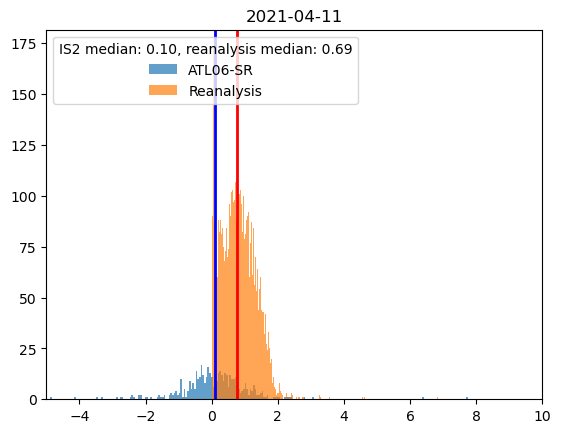

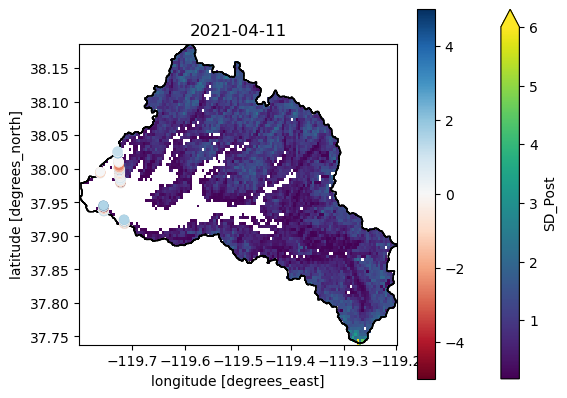

In [406]:
date_index = 23

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

IS2 median:  -0.05036776041424673
Reanalysis median:  0.8384


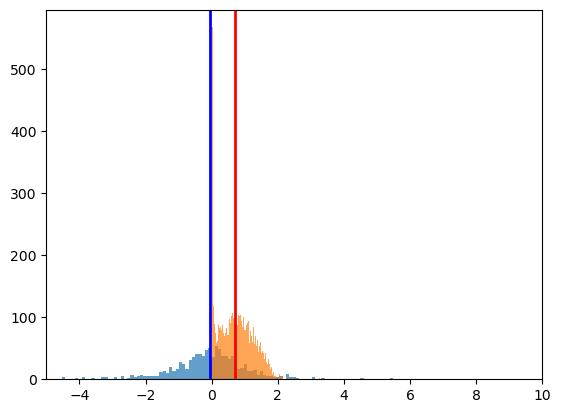

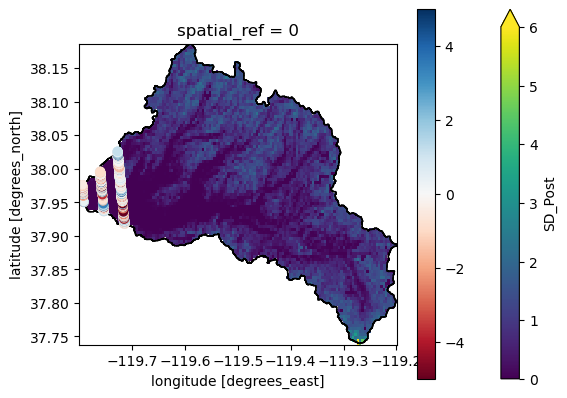

In [211]:
date_index = 23

reanalysis_test = reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7)
ax.hist(reanalysis_test.where(reanalysis_test>0).values.flatten(),\
            bins=250, alpha=0.7)
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10);

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_test.mean()>0).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)

print('IS2 median: ', np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']))
print('Reanalysis median: ',np.nanmedian(reanalysis_test.where(reanalysis_test>0.1).values.flatten()))

Text(0.5, 1.0, '2021-05-10')

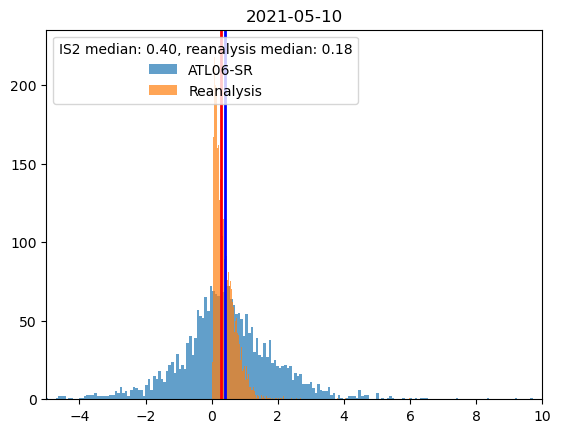

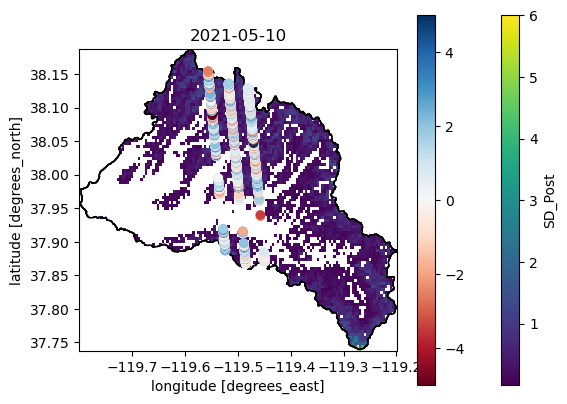

In [407]:
date_index = 24

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

Text(0.5, 1.0, '2021-05-10')

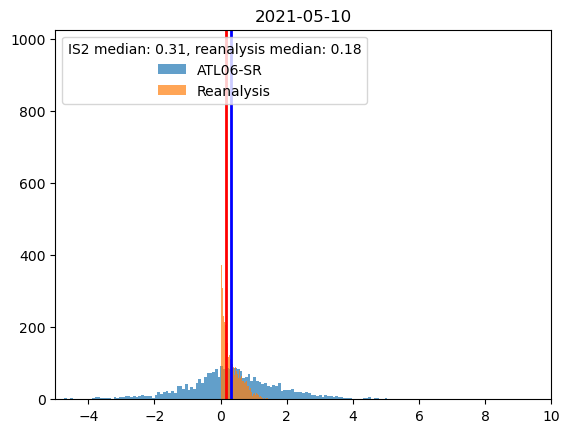

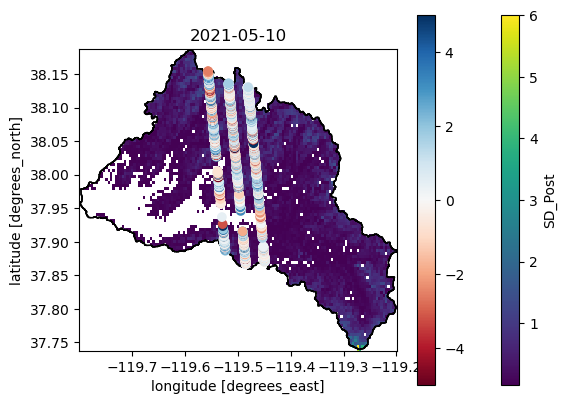

In [244]:
date_index = 24

reanalysis_test = reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_test>0).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 10)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_test>0).values.flatten()):.2f}')

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_test>0).plot(ax=ax, vmax=6)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

# print('IS2 median: ', np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']))
# print('Reanalysis median: ',np.nanmedian(reanalysis_test.where(reanalysis_test>0.1).values.flatten()))

### Calulate median IS2 value within each reanalysis grid cell:

In [425]:
reanalysis_clipped_2021[:,:,0]

<xarray.DataArray 'SD_Post' (y: 101, x: 135)> Size: 55kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(101, 135), dtype=float32)
Coordinates:
  * y            (y) float32 404B 38.18 38.18 38.18 38.17 ... 37.75 37.74 37.74
  * x            (x) float32 540B -119.8 -119.8 -119.8 ... -119.2 -119.2 -119.2
    spatial_ref  int64 8B 0
Attributes:
    Units:    meters

In [427]:
reanalysis_clipped_2021[:,:,0].rio.bounds()

(-119.79984664916992,
 37.73779451370239,
 -119.19937515258789,
 38.18672407150269)

In [429]:
reanalysis_clipped_2021[:,:,0].x

<xarray.DataArray 'x' (x: 135)> Size: 540B
array([-119.79762 , -119.793175, -119.78873 , -119.78428 , -119.77983 ,
       -119.77538 , -119.770935, -119.76649 , -119.76204 , -119.75759 ,
       -119.75314 , -119.748695, -119.74425 , -119.7398  , -119.73535 ,
       -119.7309  , -119.726456, -119.72201 , -119.71756 , -119.71311 ,
       -119.708664, -119.704216, -119.69977 , -119.69532 , -119.69087 ,
       -119.686424, -119.68198 , -119.67753 , -119.67308 , -119.66863 ,
       -119.664185, -119.65974 , -119.65529 , -119.65084 , -119.64639 ,
       -119.641945, -119.6375  , -119.63305 , -119.6286  , -119.62415 ,
       -119.619705, -119.61526 , -119.61081 , -119.60636 , -119.60191 ,
       -119.597466, -119.59302 , -119.58857 , -119.58412 , -119.57967 ,
       -119.575226, -119.57078 , -119.56633 , -119.56188 , -119.557434,
       -119.552986, -119.54854 , -119.54409 , -119.53964 , -119.535194,
       -119.53075 , -119.5263  , -119.52185 , -119.5174  , -119.512955,
       -119.50851 , -119.50406 , -119.49961 , -119.49516 , -119.490715,
       -119.48627 , -119.48182 , -119.47737 , -119.47292 , -119.468475,
       -119.46403 , -119.45958 , -119.45513 , -119.45068 , -119.446236,
       -119.44179 , -119.43734 , -119.43289 , -119.428444, -119.423996,
       -119.41955 , -119.4151  , -119.41065 , -119.406204, -119.40176 ,
       -119.39731 , -119.39286 , -119.38841 , -119.383965, -119.37952 ,
       -119.37507 , -119.37062 , -119.36617 , -119.361725, -119.35728 ,
       -119.35283 , -119.34838 , -119.34393 , -119.339485, -119.33504 ,
       -119.33059 , -119.32614 , -119.32169 , -119.317245, -119.3128  ,
       -119.30835 , -119.3039  , -119.29945 , -119.295006, -119.29056 ,
       -119.28611 , -119.28166 , -119.277214, -119.272766, -119.26832 ,
       -119.26387 , -119.25942 , -119.254974, -119.25053 , -119.24608 ,
       -119.24163 , -119.23718 , -119.232735, -119.22829 , -119.22384 ,
       -119.21939 , -119.21494 , -119.210495, -119.20605 , -119.2016  ],
      dtype=float32)
Coordinates:
  * x            (x) float32 540B -119.8 -119.8 -119.8 ... -119.2 -119.2 -119.2
    spatial_ref  int64 8B 0
Attributes:
    Units:          degrees_east
    axis:           X
    long_name:      longitude
    standard_name:  longitude
    units:          degrees_east

In [430]:
reanalysis_clipped_2021.rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [431]:
# Code adapted from https://spatial-dev.guru/2022/05/22/create-fishnet-grid-using-geopandas-and-shapely/

from shapely import geometry

# Get minX, minY, maxX, maxY
minX, minY, maxX, maxY = reanalysis_clipped_2021[:,:,0].rio.bounds()

# Create a fishnet
x, y = (minX, minY)
geom_array = []

# Polygon Size
square_size = 0.004444 # from the nsidc reanalysis documentation of the grid resolution, in degrees 
while y <= maxY:
    while x <= maxX:
        geom = geometry.Polygon([(x,y), (x, y+square_size), (x+square_size, y+square_size), (x+square_size, y), (x, y)])
        geom_array.append(geom)
        x += square_size
    x = minX
    y += square_size

fishnet = gpd.GeoDataFrame(geom_array, columns=['geometry']).set_crs(reanalysis_clipped_2021.rio.crs)
fishnet.to_file('fishnet_grid.shp')

In [432]:
fishnet

,geometry
0,"POLYGON ((-119.79985 37.73779, -119.79985 37.7..."
1,"POLYGON ((-119.7954 37.73779, -119.7954 37.742..."
2,"POLYGON ((-119.79096 37.73779, -119.79096 37.7..."
3,"POLYGON ((-119.78651 37.73779, -119.78651 37.7..."
4,"POLYGON ((-119.78207 37.73779, -119.78207 37.7..."
...,...
13867,"POLYGON ((-119.21768 38.18664, -119.21768 38.1..."
13868,"POLYGON ((-119.21324 38.18664, -119.21324 38.1..."
13869,"POLYGON ((-119.20879 38.18664, -119.20879 38.1..."
13870,"POLYGON ((-119.20435 38.18664, -119.20435 38.1..."


<Axes: title={'center': 'spatial_ref = 0'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

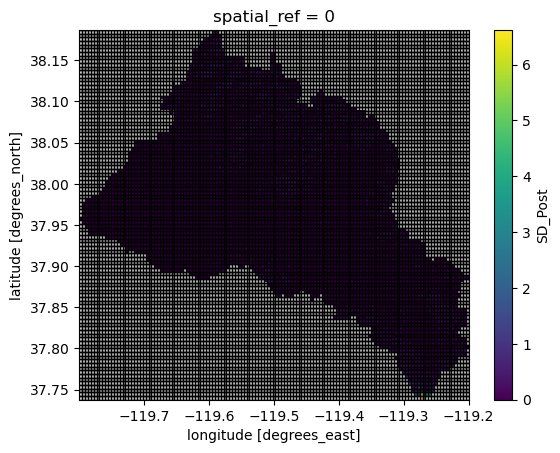

In [433]:
# Plot the fishnet on top of the coarsened ASO data:
fig, ax = plt.subplots()

reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()].plot(ax=ax)
fishnet.plot(ax=ax, edgecolor='k', facecolor='none')

(38.05, 38.1)

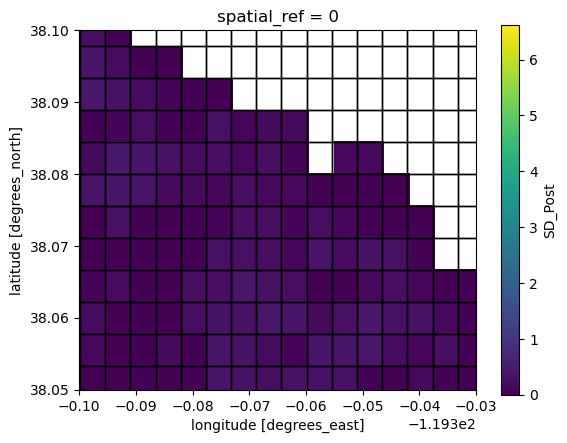

In [435]:
# Zoom in to see if cells and fishnet align:
fig, ax = plt.subplots()

reanalysis_clipped_2021[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()].plot(ax=ax)
fishnet.plot(ax=ax, edgecolor='k', facecolor='none')
ax.set_xlim(-119.4,-119.33)
ax.set_ylim(38.05,38.1)

In [436]:
fishnet["area"] = fishnet['geometry'].area

/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_22703/157063716.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  fishnet["area"] = fishnet['geometry'].area


<Axes: >

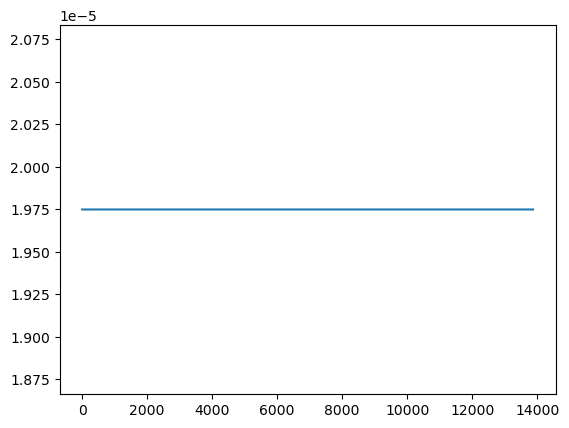

In [437]:
fishnet['area'].plot()

In [438]:
square_size**2

1.9749136e-05

In [439]:
fishnet

,geometry,area
0,"POLYGON ((-119.79985 37.73779, -119.79985 37.7...",0.00002
1,"POLYGON ((-119.7954 37.73779, -119.7954 37.742...",0.00002
2,"POLYGON ((-119.79096 37.73779, -119.79096 37.7...",0.00002
3,"POLYGON ((-119.78651 37.73779, -119.78651 37.7...",0.00002
4,"POLYGON ((-119.78207 37.73779, -119.78207 37.7...",0.00002
...,...,...
13867,"POLYGON ((-119.21768 38.18664, -119.21768 38.1...",0.00002
13868,"POLYGON ((-119.21324 38.18664, -119.21324 38.1...",0.00002
13869,"POLYGON ((-119.20879 38.18664, -119.20879 38.1...",0.00002
13870,"POLYGON ((-119.20435 38.18664, -119.20435 38.1...",0.00002


In [ ]:
pointInPolys = gpd.sjoin(atl06sr_date, fishnet_nan, how='left')